# Testing PL Overshoot in response to varying N/Nx ratios

## Overview 

The purpose of this experiment is to see whether output PL of a device undergoing the 'Switch PL' experiment depends on N/Nx, the mobile ion density over the critial ion density. To set up the initial experiment:
- Set the anion and cation densities to be equal at every run $N_\text{anion} = N_\text{cation} = N_\text{ion}$
- To begin with, I will fix $N_x$ and vary only $N_\text{ion}$
- I will then compare the varying $N_x$ against the difference in PL between the inital open circuit PL and the steady state PL, i.e. $V_\text{oc}$, as this should correspond to the existence of an overshoot vs undershoot. (NOTE: could take the integral)

It should be noted that $N_x$, the critical ion density, is given by 

$$N_x = \frac{V_{\text{bi}}}{qL_2}(\frac{L_1}{\varepsilon_1} + \frac{L_3}{\varepsilon_3})^{-1}$$

where I will approximate $V_{\text{bi}} = V_{\text{os, ss}}$

In [1]:
import os, sys
import numpy as np
import typing 
from numbers import Number
import itertools as it
from dataclasses import dataclass
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.signal import find_peaks
import xarray as xr
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../..')
    import pySIMsalabim as sim

In [2]:
session_path = os.path.join("../../", "SIMsalabim/ZimT")

## Experiment ID: PL_against_N_over_fixed_Nx - Set-Up
To being, I will generate the range of $N/Nx$ values along with the experimental file. Because I will use $V_\text{oc, ss}$ to calculate $N_x$, I can't actually do that until after the experiements have been run, as I expect $V_\text{oc, ss}$ to be slightly different for run. However, from past experience, $V_\text{oc, ss}$ for this device was around $1.2V$ which is what I will use to calculate an approximate $N_x$. I will then use this approximate value to set the values of $N$ I want to check

### Set up

In [3]:
experiment_id = "PL_against_N_over_fixed_Nx"

In [4]:
# Fixed for the simulation
ion_mobility = 1E-15 
absorber_length = 500E-9 # Taken from param set-up files

# Layer params taken from the set-up files
layer1_length = 25E-9
layer1_relative_permittivity = 5
layer1_permittivity = layer1_relative_permittivity * scipy.constants.epsilon_0

layer3_length = 10E-9
layer3_relative_permittivity = 3
layer3_permittivity = layer3_relative_permittivity * scipy.constants.epsilon_0

# Get approximate N_x value
approximate_Vocss = 1.2

def get_critical_ion_density(V: float, absorber_length: float, L_1: float, L_3: float, 
                             epsilon_1: float, epsilon_3: float) -> float:
    q = scipy.constants.elementary_charge
    critical_ion_density = (V/(q*absorber_length))*(L_1/epsilon_1 + L_3/epsilon_3)**(-1)
    return critical_ion_density

approximate_N_x = get_critical_ion_density(approximate_Vocss, absorber_length, layer1_length, 
                                           layer3_length, layer1_permittivity, layer3_permittivity)

# Get range of N values from an order of magnitude below 
N_ion_lower_bound = approximate_N_x * 1E-1
N_ion_upper_bound = approximate_N_x * 1E1
N_ion_values = np.geomspace(N_ion_lower_bound, N_ion_upper_bound, 16)


experiment_parameters = {
    "l2.mu_cation" : ion_mobility,
    "l2.mu_anion" : ion_mobility,
    "l2.N_cation" : N_ion_values,
    "l2.N_anion" : N_ion_values
}

output_files = {
    "tjFile" : "tj.dat",
    "varFile" : "varFile.dat"
}

In [5]:
# From the arguments and values, create a parameter .txt file alongside a .sh file containing all the various experiments to run
import uuid 
import hashlib

def get_UUID_from_string(s: str) -> uuid.UUID:
    '''Creates a UUID object based off a passed string'''
    hex_string = hashlib.md5(s.encode("UTF-8")).hexdigest()
    return uuid.UUID(hex=hex_string)

def generate_experiment_files(experiment_parameters: dict[str, float | np.ndarray], session_path: str, experiment_id: str, 
                              tVG_file: str = "tVG.txt", output_files: dict[str, str] = {"tjFile" : "tj.dat"}) -> str:
    '''Generates a bash script where each line corresponds to a specified experiment alongside a .txt file containing all passed parameters'''
    
    # Set up the header of the space seperated parameter file .txt
    parameter_file_string = "UUID "
    for parameter in experiment_parameters.keys(): 
        parameter_file_string += f"{parameter} "
    parameter_file_string = parameter_file_string.strip() + '\n'
    
    # Set up the experiment_zimt_commands file
    zimt_command = "./zimt"
    zimt_commands_file_string = ""
    
    # Set up the tVG command flag and argument
    tVG_file_command_line_argument = f" -tVGFile {tVG_file}"
    
    # Convert the passed experiment parameters to a dataFrame for easy iteration, and parse each row into the relevant files
    experiment_parameters_dataframe = pd.DataFrame(experiment_parameters)
    for _, run in experiment_parameters_dataframe.iterrows():
        run_parameters = ""
        run_command_line_arguments = ""
        
        for parameter, value in run.items():
            run_parameters += f"{value:.2e} "
            run_command_line_arguments += f" -{parameter} {value:.2e}"
        
        run_uuid = str(get_UUID_from_string(run_parameters))
        run_uuid_savefile_tag = f"_{run_uuid}"
        
        for savefile_flag, savefile_name in output_files.items():
            savefile_name_base, savefile_name_extension = os.path.splitext(savefile_name)
            savefile_name = savefile_name_base + f"__{experiment_id}_" + run_uuid_savefile_tag + savefile_name_extension
            
            run_command_line_arguments += f" -{savefile_flag} {savefile_name}"
            
            
        parameter_file_string += run_uuid + " " + run_parameters.strip() + "\n"
        zimt_commands_file_string += zimt_command + tVG_file_command_line_argument + run_command_line_arguments + "\n"
        
    # Save experiment parameters
    parameter_file_name = f"experiment__{experiment_id}__parameters.txt"
    parameter_file_path = os.path.join(session_path, parameter_file_name)
    with open(parameter_file_path, 'w') as file:
        file.write(parameter_file_string)
        
    # Save zimt commands 
    zimt_commands_file_name = f"experiment__{experiment_id}__zimt_commands.sh"
    zimt_commands_file_path = os.path.join(session_path, zimt_commands_file_name)
    with open(zimt_commands_file_path, 'w') as file:
        file.write(zimt_commands_file_string)
        
    return parameter_file_path

In [6]:
# Generate the experiment files 
parameter_file_path = generate_experiment_files(experiment_parameters, session_path, experiment_id, tVG_file="tVG_high_res.dat", output_files=output_files)

### Experiment Execution
Run the generated experiment bash script commands with 

```~$ parallel :::: experiment__PL_against_N_over_fixed_Nx__zimt_commands.sh```

Test the generated experiment bash script commands with 

```~$ parallel --dry-run :::: experiment__PL_against_N_over_fixed_Nx__zimt_commands.sh```


### Analysis
#### Read Data

In [7]:
# Move the run data to a subdirectory for safe storage 
experiment_data_save_directory = f"data_{experiment_id}"

In [8]:
experiment_parameter_dataframe = pd.read_csv(parameter_file_path, sep=r'\s+')

In [9]:
# For the sake of clarity, I'll use typing here
type ExperimentDict = dict[str, float | pd.DataFrame]
    
def zimt_run_data_to_list(save_directory_path: str):
    """Read in run uuid, parameters, and data and store in an list of dictionaries"""

    zimt_runs: list[ExperimentDict] = []

    # Store each experimental run, including params and tj_data, as a dict and add to zimt_runs
    for _, row in experiment_parameter_dataframe.iterrows():
        zimt_run: ExperimentDict = {}    
        
        for parameter, value in row.items():
            zimt_run[parameter] = value
        
        zimt_run_tj_filename = f"tj__{experiment_id}__{zimt_run["UUID"]}.dat"
        zimt_run_file_path = os.path.join(save_directory_path, zimt_run_tj_filename)
        zimt_run_tj_data = pd.read_csv(zimt_run_file_path, sep=r'\s+')
        zimt_run['tj_data'] = zimt_run_tj_data
        
        zimt_run_varFile_filename = f"varFile__{experiment_id}__{zimt_run["UUID"]}.dat"
        zimt_run_file_path = os.path.join(save_directory_path, zimt_run_varFile_filename)
        zimt_run_varFile_data = pd.read_csv(zimt_run_file_path, sep=r'\s+')
        zimt_run['var_file'] = zimt_run_varFile_data
        
        zimt_runs.append(zimt_run)
        
    return zimt_runs

In [10]:

type ExperimentDict = dict[str, float | pd.DataFrame]
    
def zimt_data_to_dataset(save_directory_path: str):
    """Read in run uuid, parameters, and data and store in an list of dictionaries"""

    zimt_runs_transient: list = []
    zimt_runs_Voc_ss: list = []

    # Store each experimental run, including params and tj_data, as a dict and add to zimt_runs
    for _, row in experiment_parameter_dataframe.iterrows():
        zimt_run_uuid = row["UUID"]
        
        # Read in the tj_data 
        zimt_run_tj_filename = f"tj__{experiment_id}__{zimt_run_uuid}.dat"
        zimt_run_file_path = os.path.join(save_directory_path, zimt_run_tj_filename)
        zimt_run_tj_data = pd.read_csv(zimt_run_file_path, sep=r'\s+')
        
        # Convert the tj_data to two datasets, one containing the run data, and the other the steady state Voc
        tj_transient_data = zimt_run_tj_data[:-1].set_index('t') # Set the index so from_dataframe reads time as a coordinate
        tj_steady_state_Voc_data = zimt_run_tj_data.set_index('t').tail(1)
        tj_transient_dataset = xr.Dataset.from_dataframe(tj_transient_data)
        tj_steady_state_Voc_dataset = xr.Dataset.from_dataframe(tj_steady_state_Voc_data)
        
        # Read in the var data 
        zimt_run_varFile_filename = f"varFile__{experiment_id}__{zimt_run_uuid}.dat"
        zimt_run_file_path = os.path.join(save_directory_path, zimt_run_varFile_filename)
        zimt_run_varFile_data = pd.read_csv(zimt_run_file_path, sep=r'\s+')
        
        # Conver the var data to two datasets, one containing run data, and the other Voc steady state data
        var_data = zimt_run_varFile_data.set_index(["time", "x"]) # Do this to set time and x as coordinates when read later
        number_of_x_positions = len(var_data.index.levels[1])
        var_transient_data = var_data[:-number_of_x_positions] # Remove the last steady state sim
        var_steady_state_Voc_data = var_data[-number_of_x_positions:]
        var_transient_dataset = xr.Dataset.from_dataframe(var_transient_data)
        var_steady_state_Voc_dataset = xr.Dataset.from_dataframe(var_steady_state_Voc_data)
        
        # Merge the tj and var datasets along the time coordinate
        tj_transient_dataset = tj_transient_dataset.rename({"t": "time"})
        tj_steady_state_Voc_dataset = tj_steady_state_Voc_dataset.rename({"t" : "time"})
        
        run_transient_dataset = xr.merge([tj_transient_dataset, var_transient_dataset], compat='override')
        run_steady_state_Voc_dataset = xr.merge([tj_steady_state_Voc_dataset, var_steady_state_Voc_dataset], compat='override')
        
        # Add the run parameters as extra-dimensions 
        parameter_dims_and_coords = {
            "l2_N_ion" : [row["l2.N_cation"]],
            "l2_mu_ion" : [row["l2.mu_cation"]]
        }
        # for parameter, value in row.items():
        #     parameter = parameter.replace(".", "_") if "." in parameter else parameter
        #     parameter_dims_and_coords[parameter] = [value]
        
        run_transient_dataset = run_transient_dataset.expand_dims(parameter_dims_and_coords)
        run_steady_state_Voc_dataset = run_steady_state_Voc_dataset.expand_dims(parameter_dims_and_coords)
        # run_transient_dataset.attrs = {"UUID": row["UUID"]}
        
        zimt_runs_transient.append(run_transient_dataset)
        zimt_runs_Voc_ss.append(run_steady_state_Voc_dataset)
    
    return zimt_runs_transient, zimt_runs_Voc_ss

In [11]:
experiment_data_save_path = os.path.join(session_path, experiment_data_save_directory)
zimt_runs = zimt_run_data_to_list(experiment_data_save_path)

In [12]:
zimt_xarray_runs, zimt_run_steady_state_Voc_dataset = zimt_data_to_dataset(experiment_data_save_path)
zimt_run_dataset = xr.combine_by_coords(zimt_xarray_runs)
zimt_Voc_dataset = xr.combine_by_coords(zimt_run_steady_state_Voc_dataset)

In [13]:
zimt_run_dataset = zimt_run_dataset.isel(l2_mu_ion=0)
zimt_Voc_dataset = zimt_Voc_dataset.isel(l2_mu_ion=0)

#### Calculate Critical Ion Density and get minimum PL time

In [14]:
for run in zimt_runs:
    V_ocss = run["tj_data"]["Vext"].values[-1]
    
    run["N_x"] = get_critical_ion_density(V_ocss, absorber_length, layer1_length, 
                                          layer3_length, layer1_permittivity, layer3_permittivity)

In [15]:
# Get minimum PL time which we will call delta_t
for run in zimt_runs: 
    peaks = find_peaks(1/run["tj_data"]["JdirL2"].values, height=0.06)[0]
    run["delta_t"] = run["tj_data"]["t"].iloc[peaks[0]] if len(peaks) > 0 else None

In [16]:
# Calculate the difference in V_oc,ini and Voc for each run 
for run in zimt_runs:
    PL_ocini = run["tj_data"]["JdirL2"].values[2]
    PL_ocss = run["tj_data"]["JdirL2"].values[-1]
    delta_PL = PL_ocini - PL_ocss
    run["delta_PL"] = delta_PL

In [17]:
zimt_runs[0]["delta_t"]

np.float64(8964.69785)

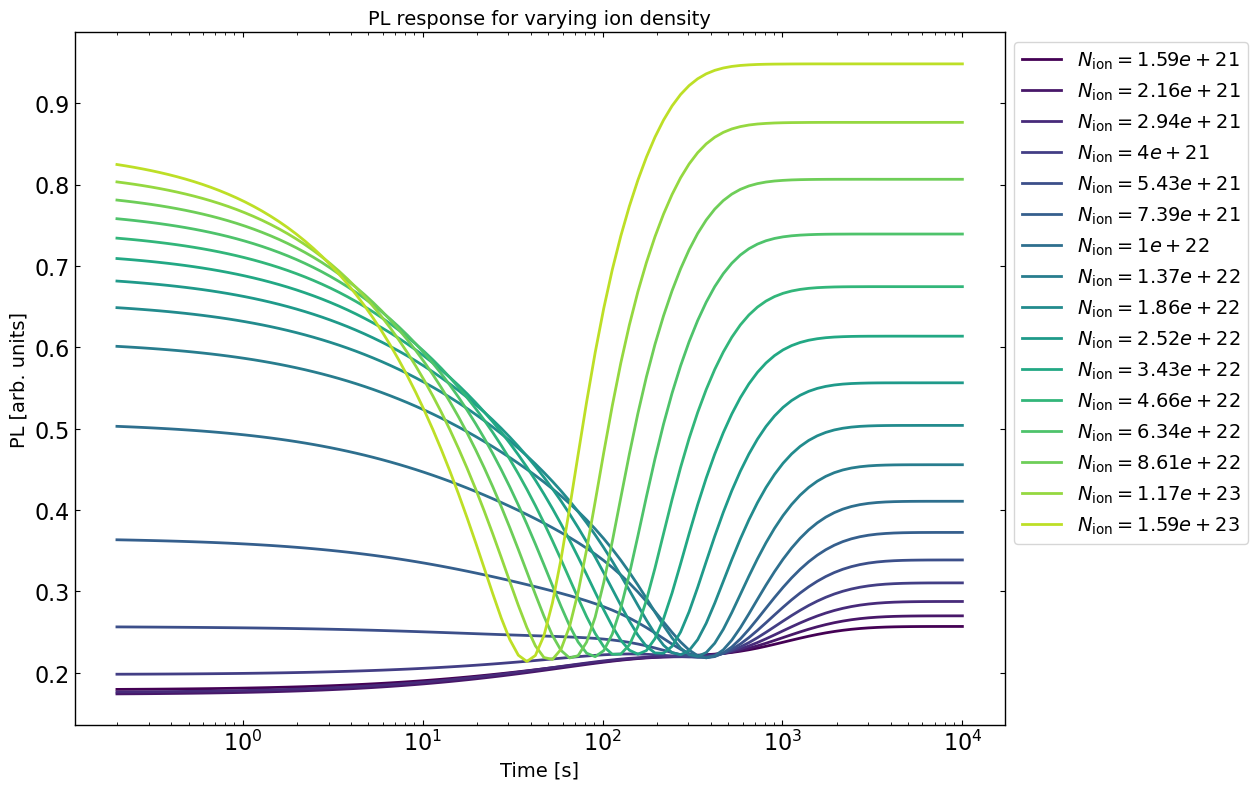

In [46]:
import matplotlib
colormap=matplotlib.colormaps.get_cmap("viridis")
colors=colormap(np.linspace(0,0.9,len(zimt_runs)))
    
plt.figure(figsize=(12,9))

for index, run in enumerate(zimt_runs):
    label = f"$N_\\text{{ion}} = {run["l2.N_cation"]}$"
    plt.plot(run["tj_data"]["t"][2:-1], run["tj_data"]['JdirL2'][2:-1], label=label,color=colors[index])
    # print(run["delta_t"])
    # if run["delta_t"] is not None:
    #     plt.axvline(run["delta_t"], linestyle='--', color=colors[index])
    
plt.xscale('log')
plt.xlabel("Time [s]")
plt.ylabel("PL [arb. units]")
plt.title("PL response for varying ion density")
# plt.legend(bbox_to_anchor=(1,1),ncols=2)
plt.legend(ncols=1, bbox_to_anchor=(1,1))
plt.savefig("PL response for varying mobile ion densities.pdf", format="pdf", bbox_inches='tight')
plt.show()

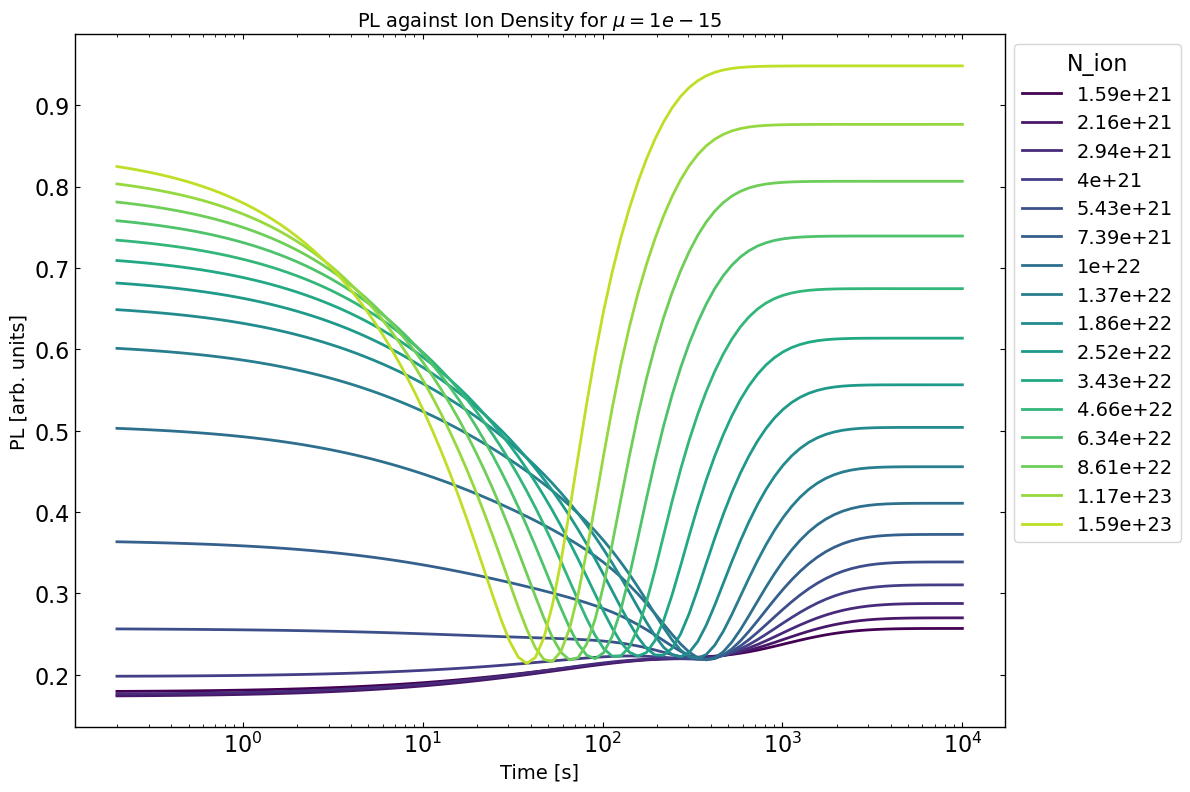

In [19]:
# Try the same thing with the zimt-run dataset
from cycler import cycler

# Plot the PL for each ion_density 
PL_data = zimt_run_dataset.rename({"JdirL2" : "PL"})
PL_data = PL_data.PL
PL_data = PL_data.where(PL_data.time >= 0.2, drop=True)

colormap = matplotlib.colormaps.get_cmap("viridis")
colors = colormap(np.linspace(0,0.9, len(PL_data.l2_N_ion)))

custom_cycler = cycler(color=colors)
fig = plt.figure(figsize=(12,9))

ax = fig.add_subplot()
ax.set_prop_cycle(custom_cycler)
lines = PL_data.plot.line(x='time', hue="l2_N_ion", xscale='log', add_legend=False, ax=ax)
labels = PL_data.l2_N_ion.values
ax.legend(labels, title="N_ion", bbox_to_anchor=(1,1))
ax.set_xlabel("Time [s]")
ax.set_ylabel("PL [arb. units]")
ax.set_title(f"PL against Ion Density for $\\mu = {PL_data.l2_mu_ion.values}$")
plt.show()

In [20]:
# Get peak lifetimes 
peak_times = []

for ion_density, PL_curve in PL_data.groupby("l2_N_ion"):
    peaks = find_peaks(1/PL_curve.isel(l2_N_ion=0))[0]
    
    if len(peaks) >= 1:
        peak_time = PL_curve.isel(time=peaks[0]).time.item()
    else:
        peak_time = None 
        
    peak_times.append(peak_time)

# Store the peak times with the PL data
peak_times_data = xr.DataArray(peak_times, dims=("l2_N_ion"), coords={PL_data.l2_N_ion.name : PL_data.l2_N_ion.values})
peak_times_dataset = peak_times_data.to_dataset(name="peak_time")
PL_dataset = PL_data.to_dataset(name="PL")
PL_dataset = PL_dataset.merge(peak_times_dataset)

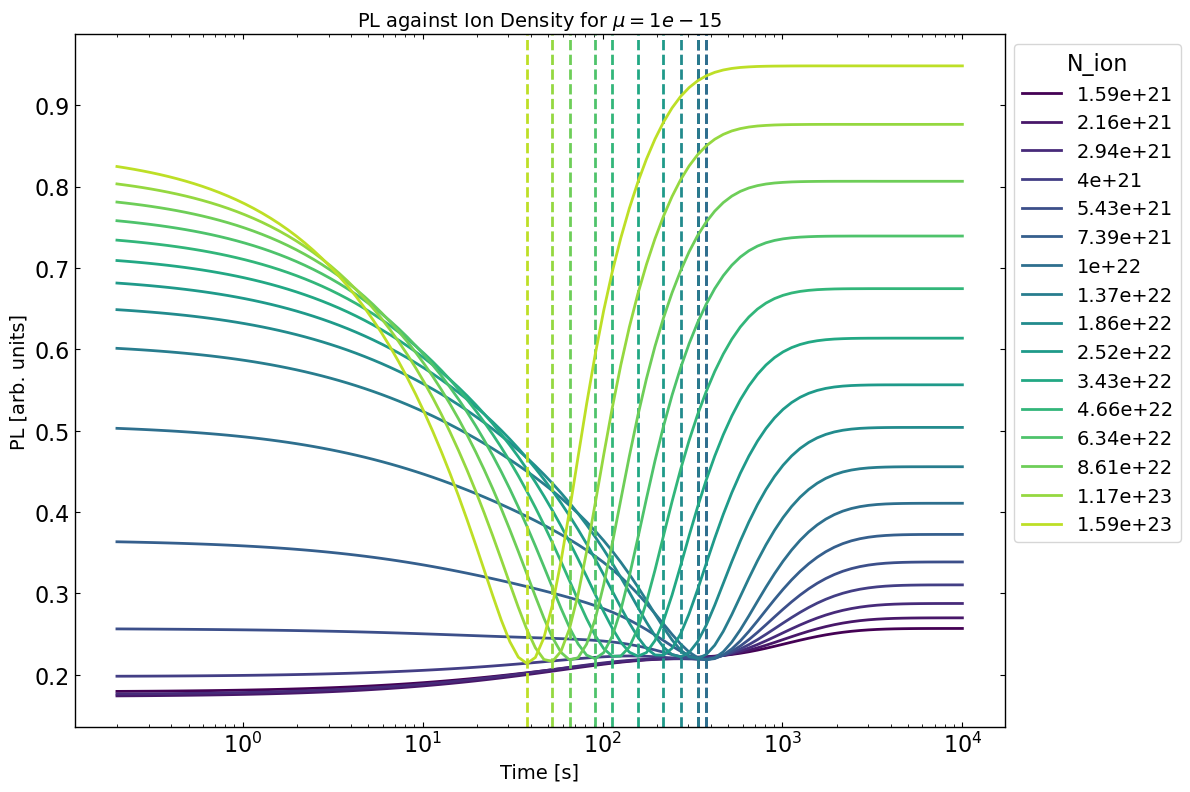

In [21]:
# Plot the PL data with the peak times included
PL_data = PL_dataset.PL 
peak_times_data = PL_dataset.peak_time

colormap = matplotlib.colormaps.get_cmap("viridis")
colors = colormap(np.linspace(0,0.9, len(PL_data.l2_N_ion)))

fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot()

for index, PL_data_group in enumerate(PL_data.groupby("l2_N_ion")):
    # Unpack the PL_data_group
    ion_density, PL_curve = PL_data_group
    
    # Plot the PL_curve
    curve = PL_curve.plot.line(x="time", xscale="log", color=colors[index], ax=ax, label=f"{ion_density}")
    peak_time = peak_times_data.sel(l2_N_ion=ion_density).item()
    
    # Check the peak time isn't none and plot if it's safe
    if peak_time is not None and peak_time < 1E3:
        ax.axvline(peak_time, linestyle='--', color=colors[index])

labels = PL_data.l2_N_ion.values
ax.legend(title="N_ion", bbox_to_anchor=(1,1))
ax.set_xlabel("Time [s]")
ax.set_ylabel("PL [arb. units]")
ax.set_title(f"PL against Ion Density for $\\mu = {PL_data.l2_mu_ion.values}$")
plt.show()

In [22]:
zimt_Voc_dataset.isel(l2_N_ion=0).isel(time=0, drop=True).JdirL2.item()

0.2569059307

Now that we have the peak times, I want to plot the graphs for the initial rise to Voc, minimum PL, and Voc steady state

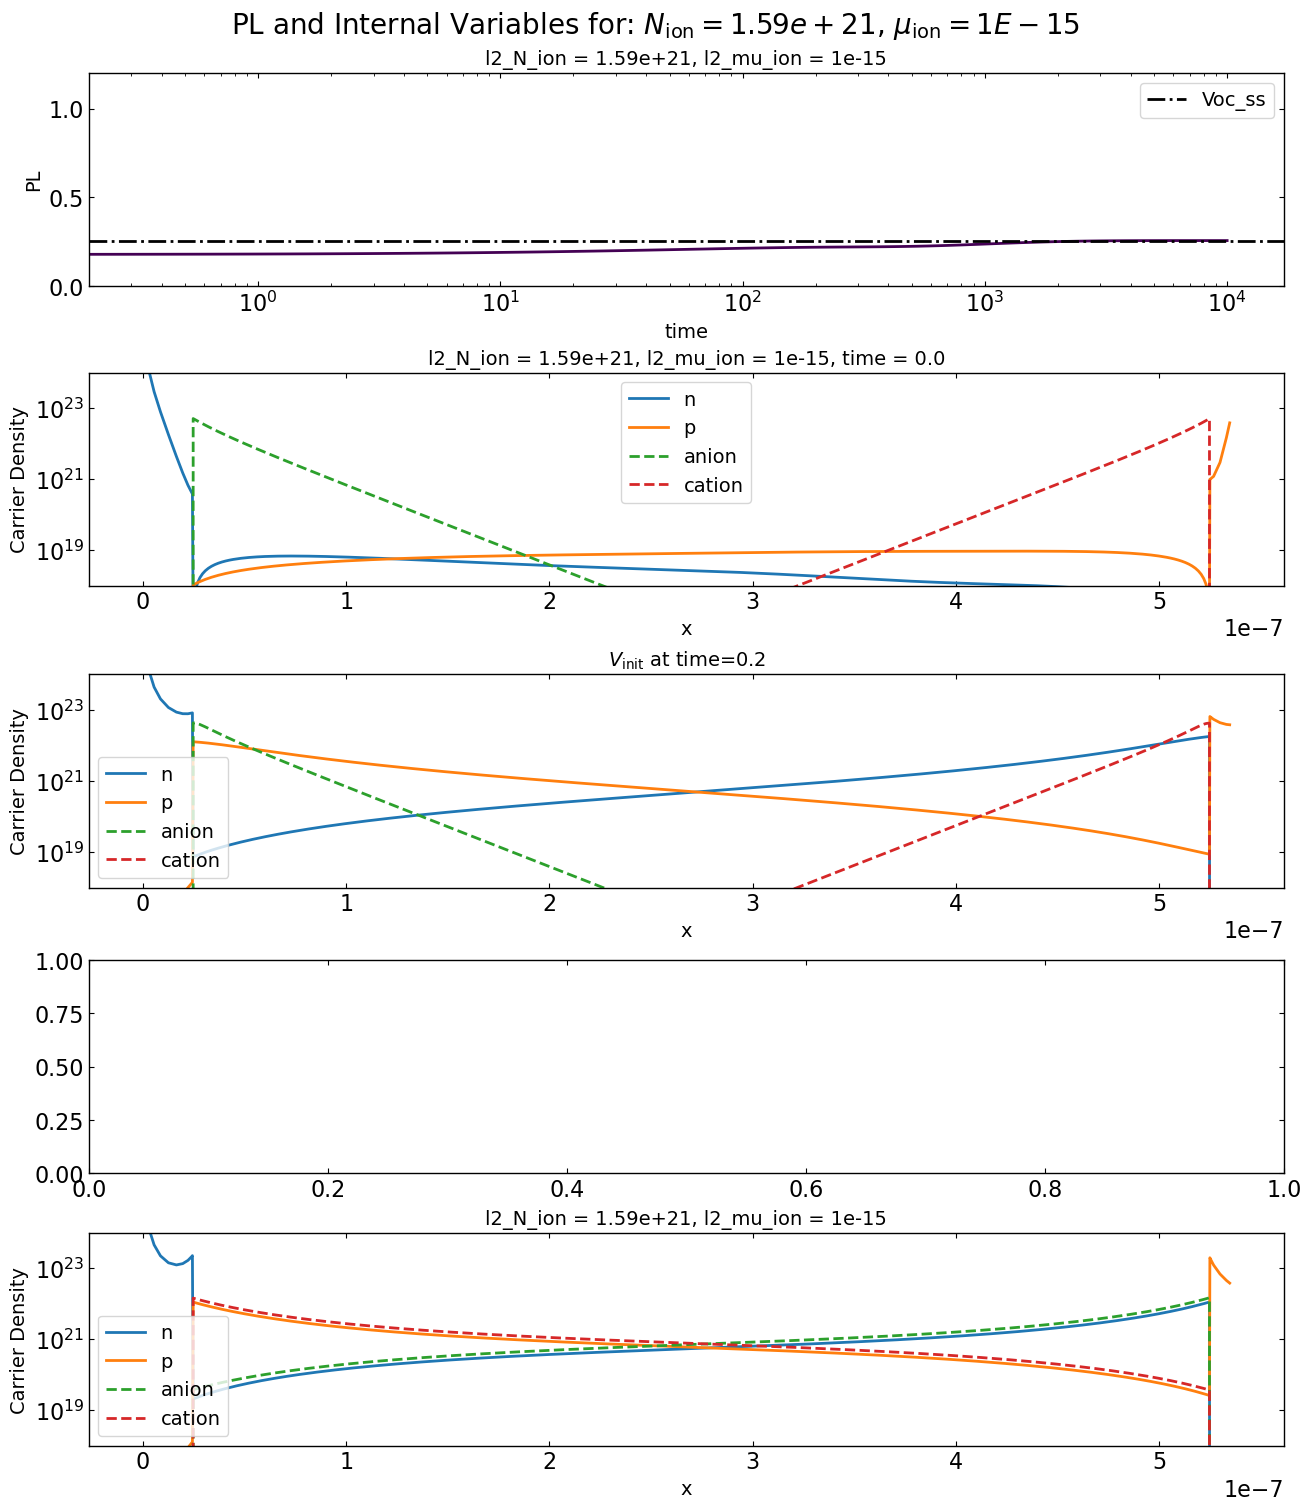

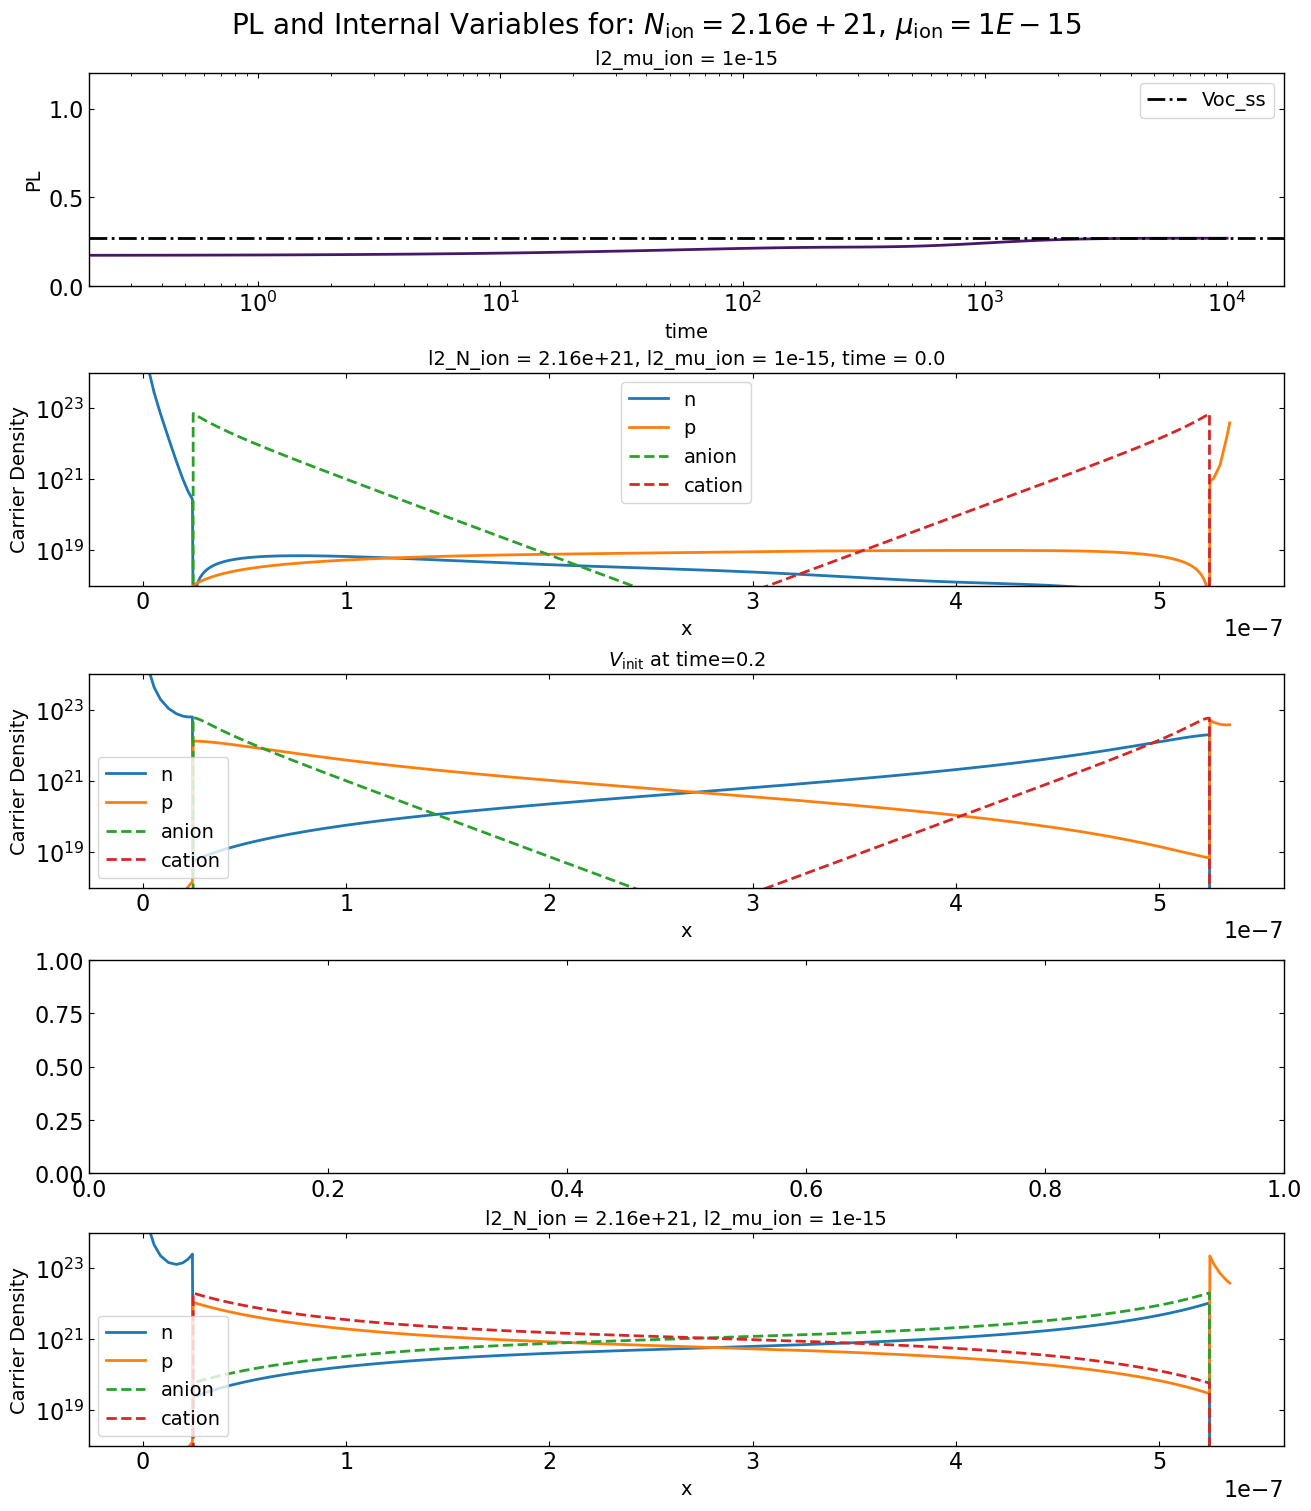

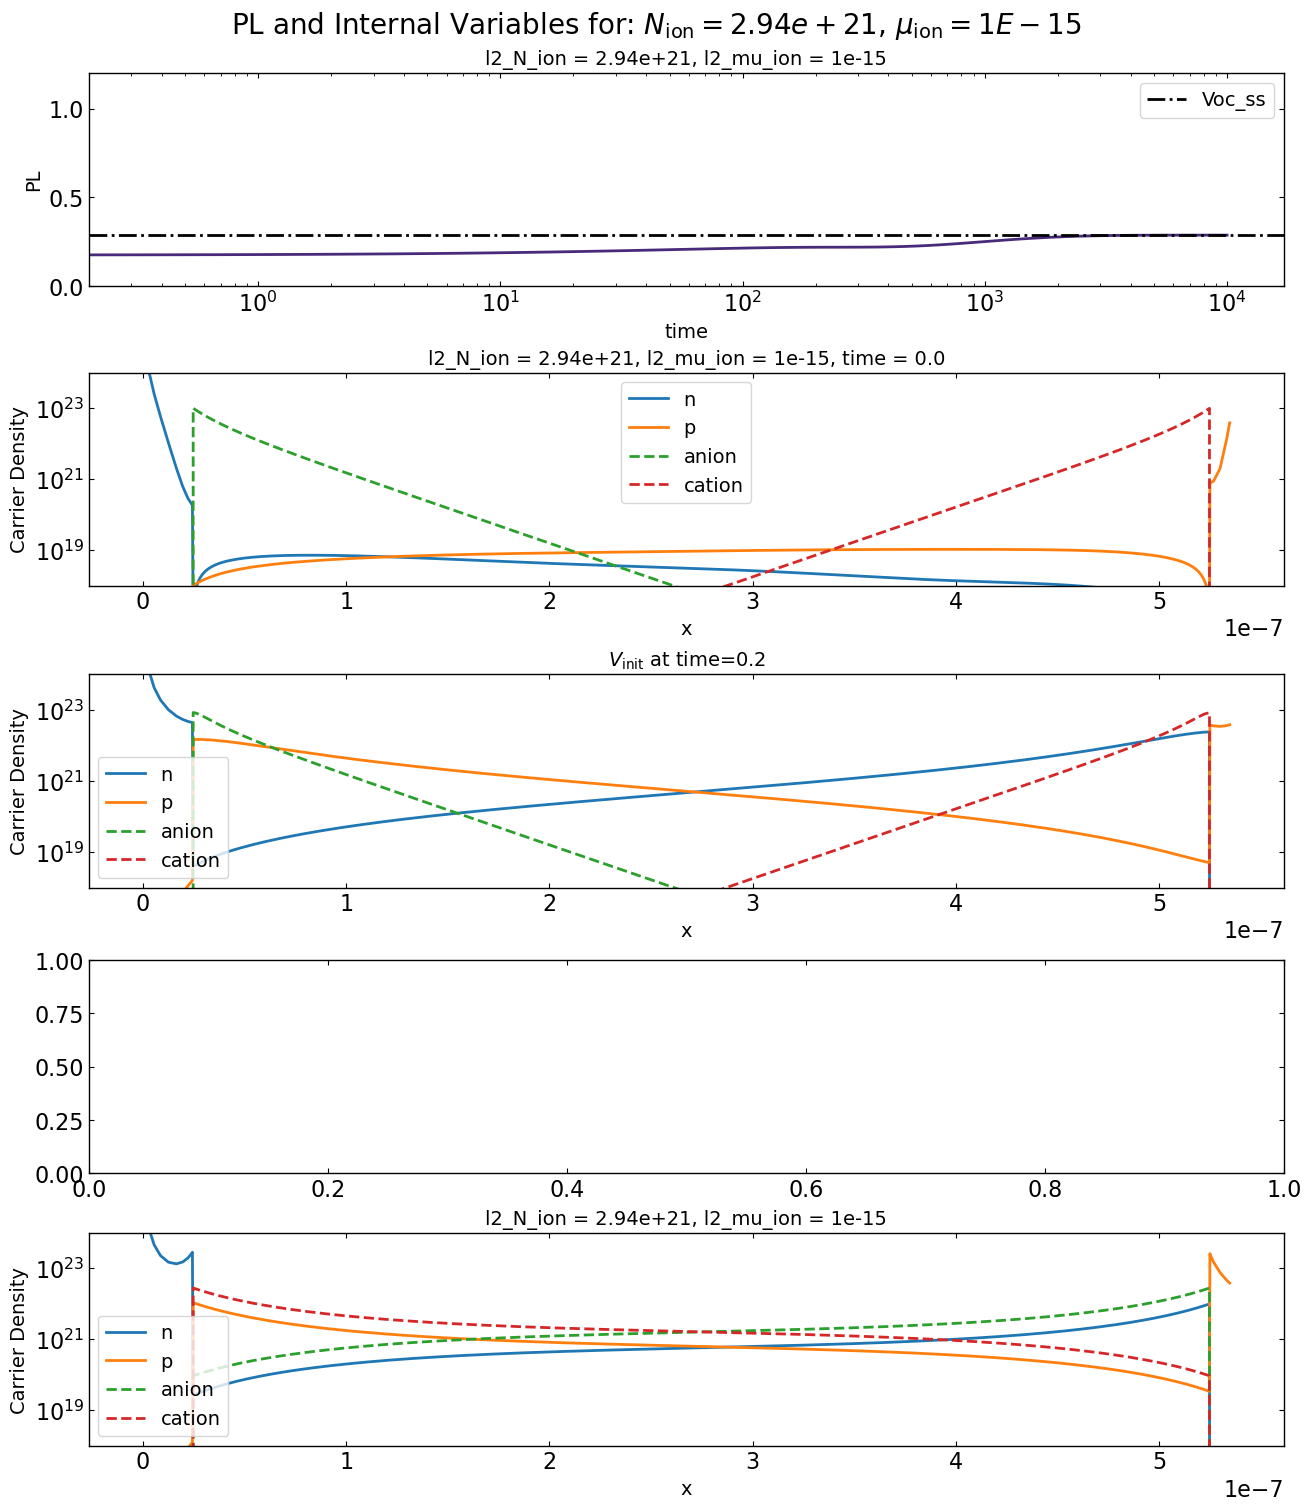

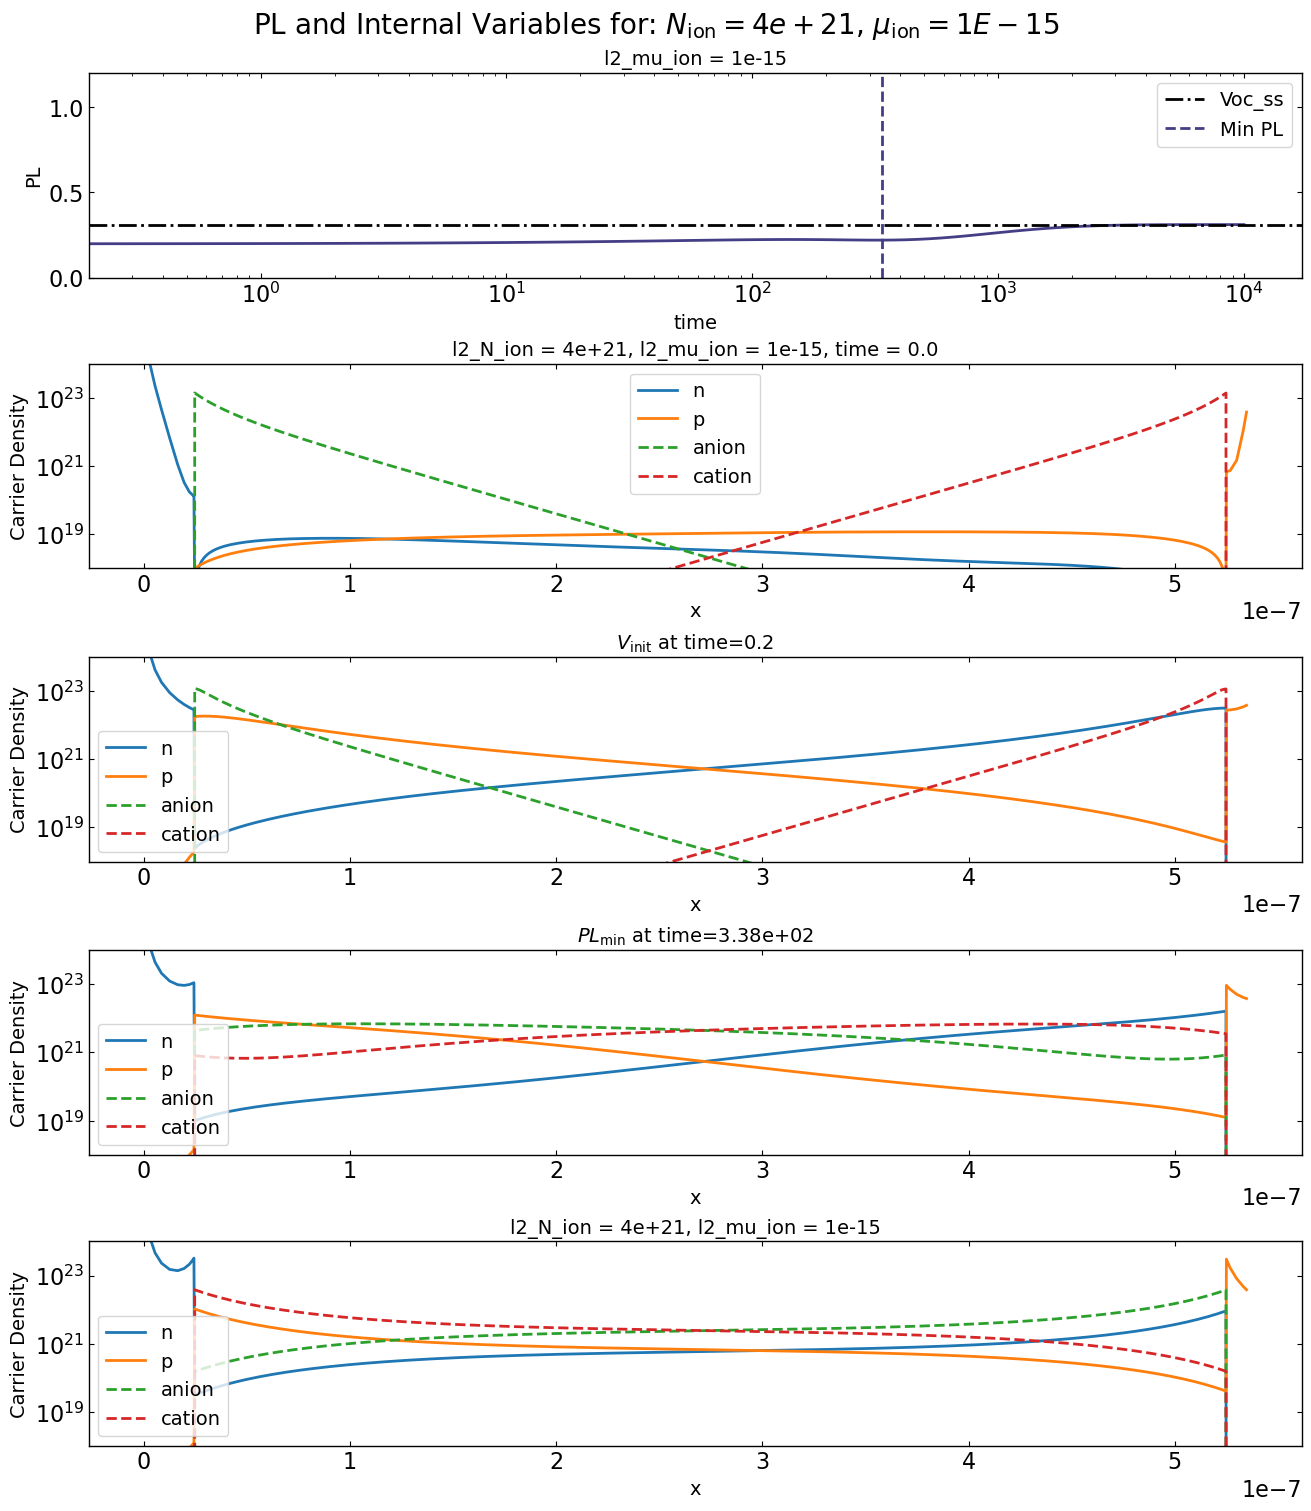

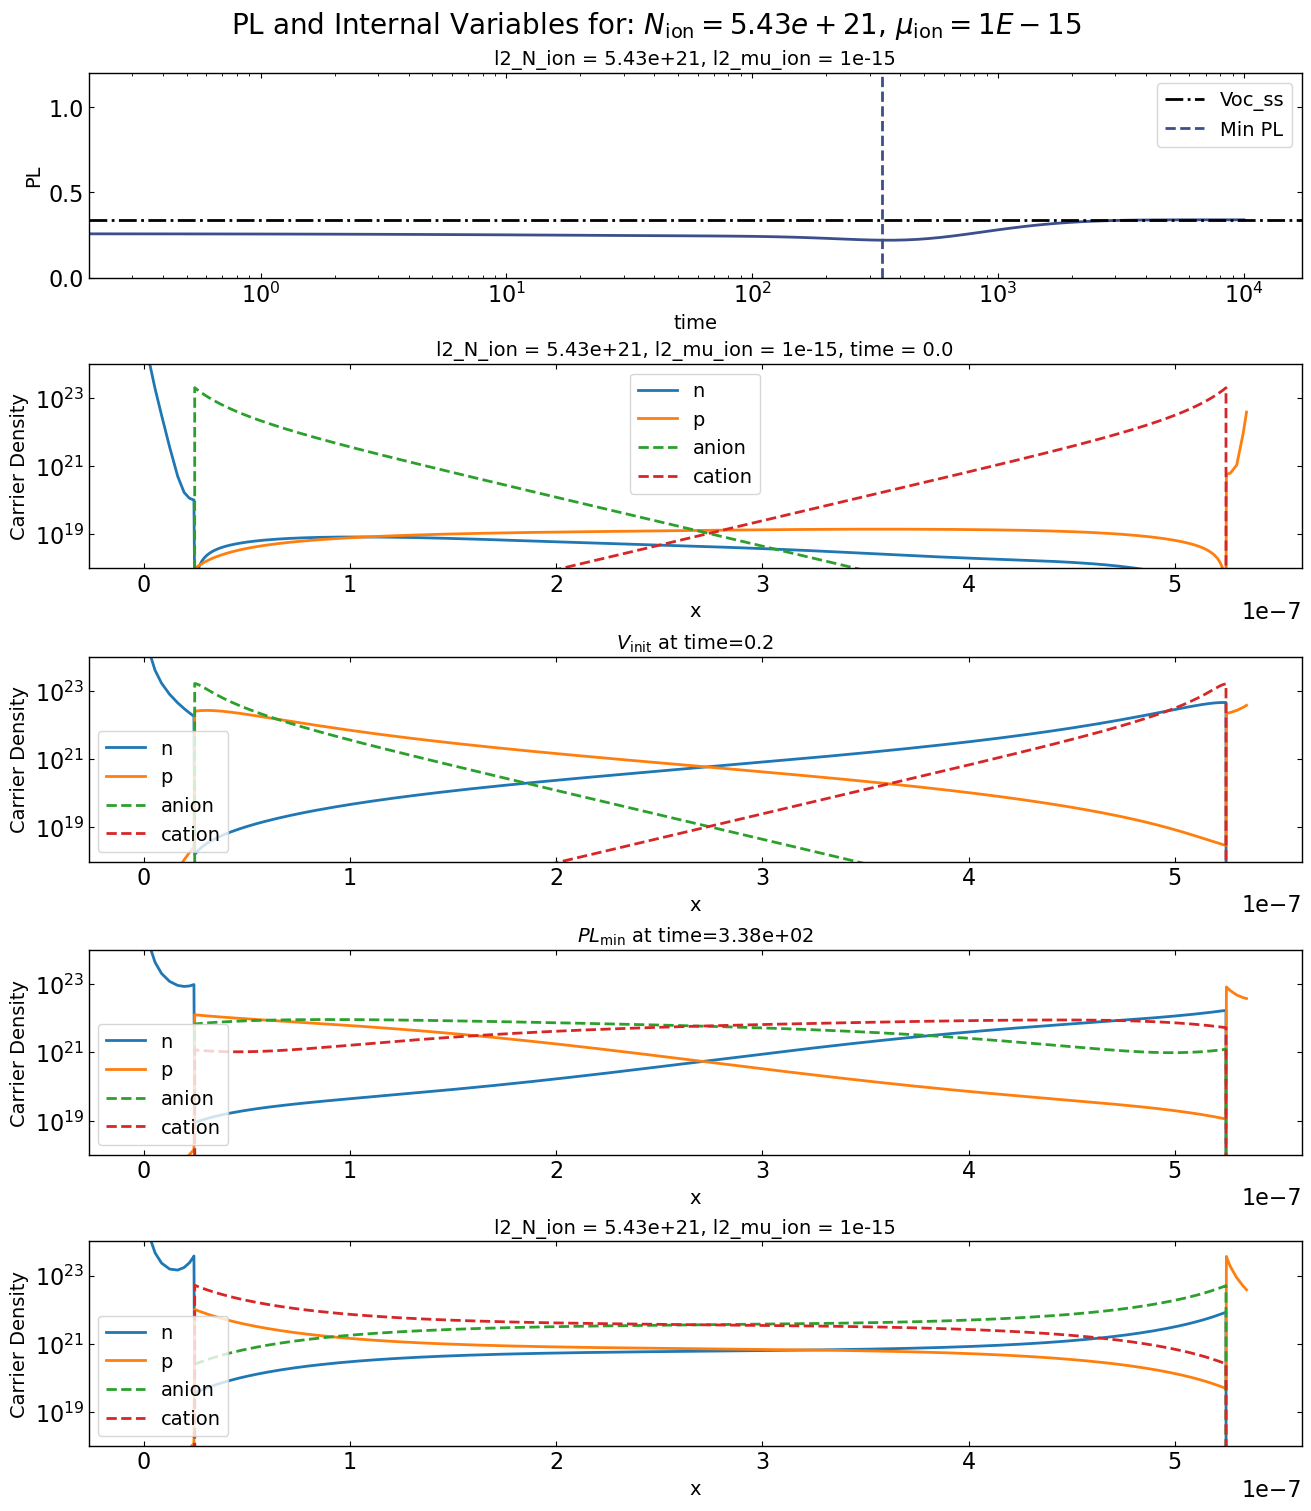

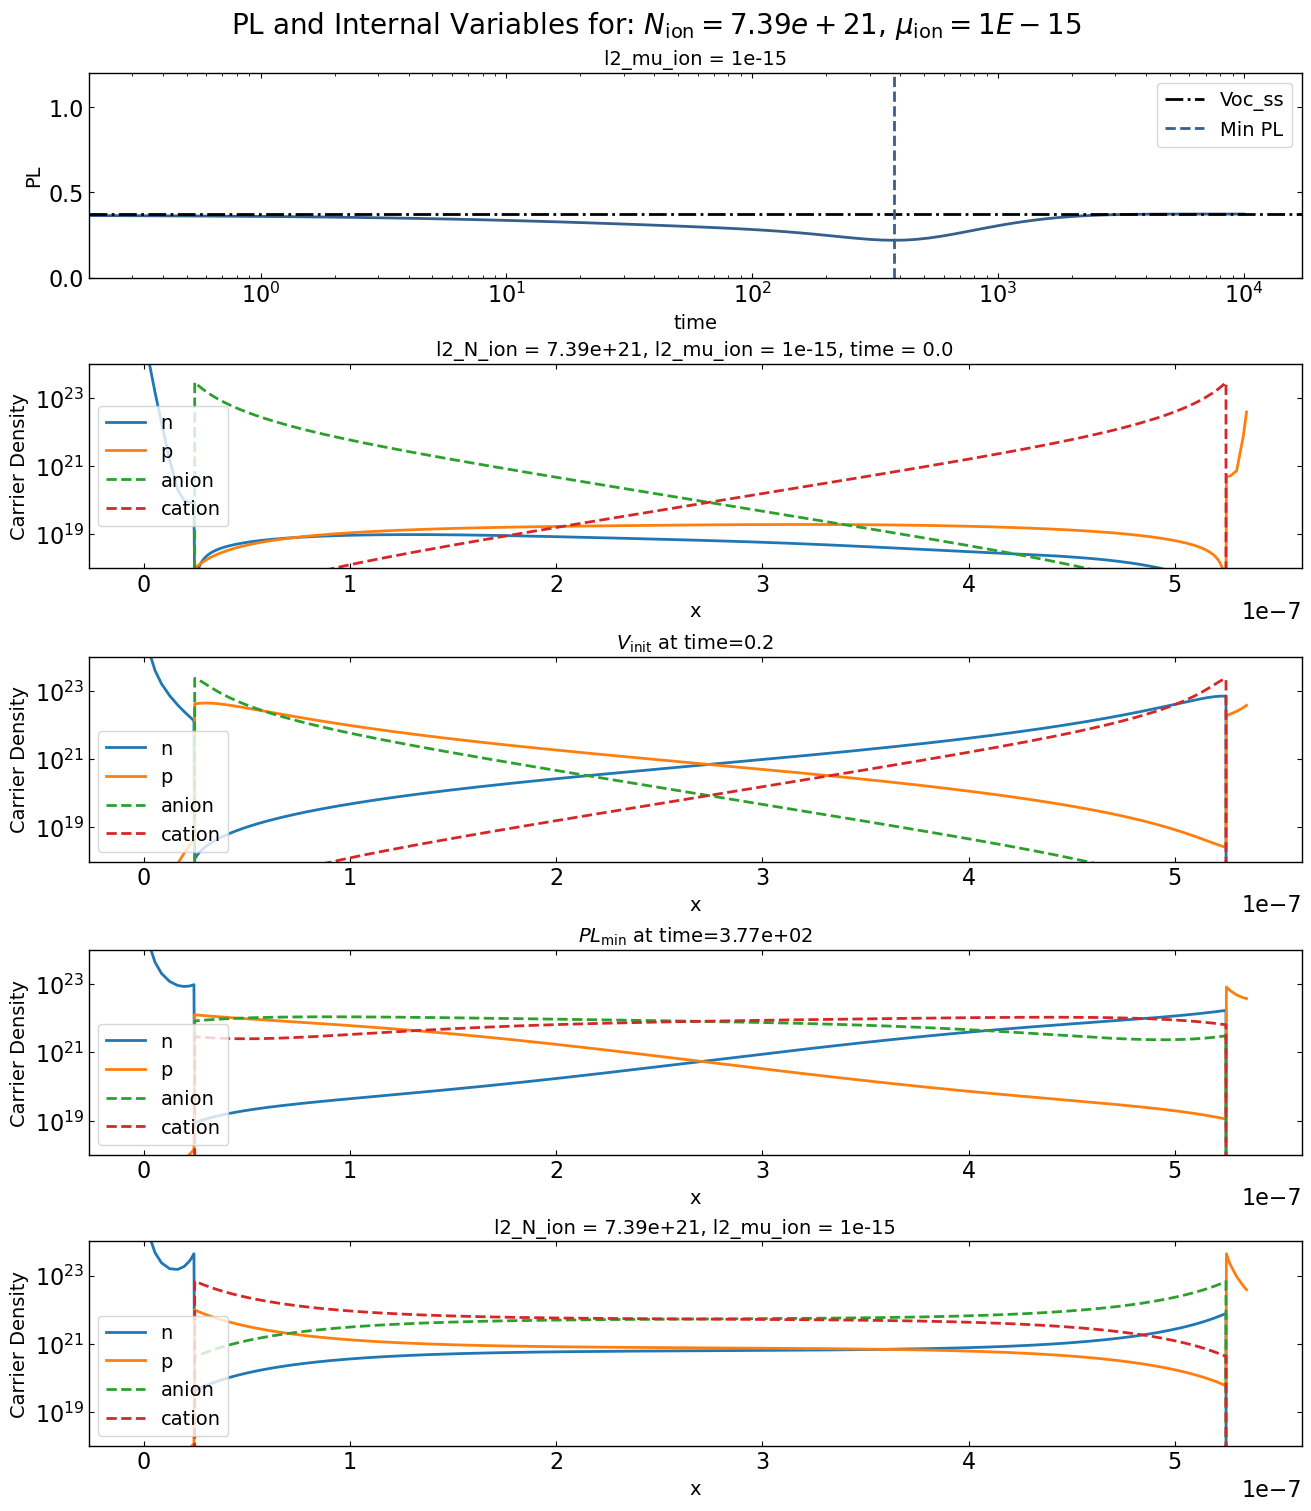

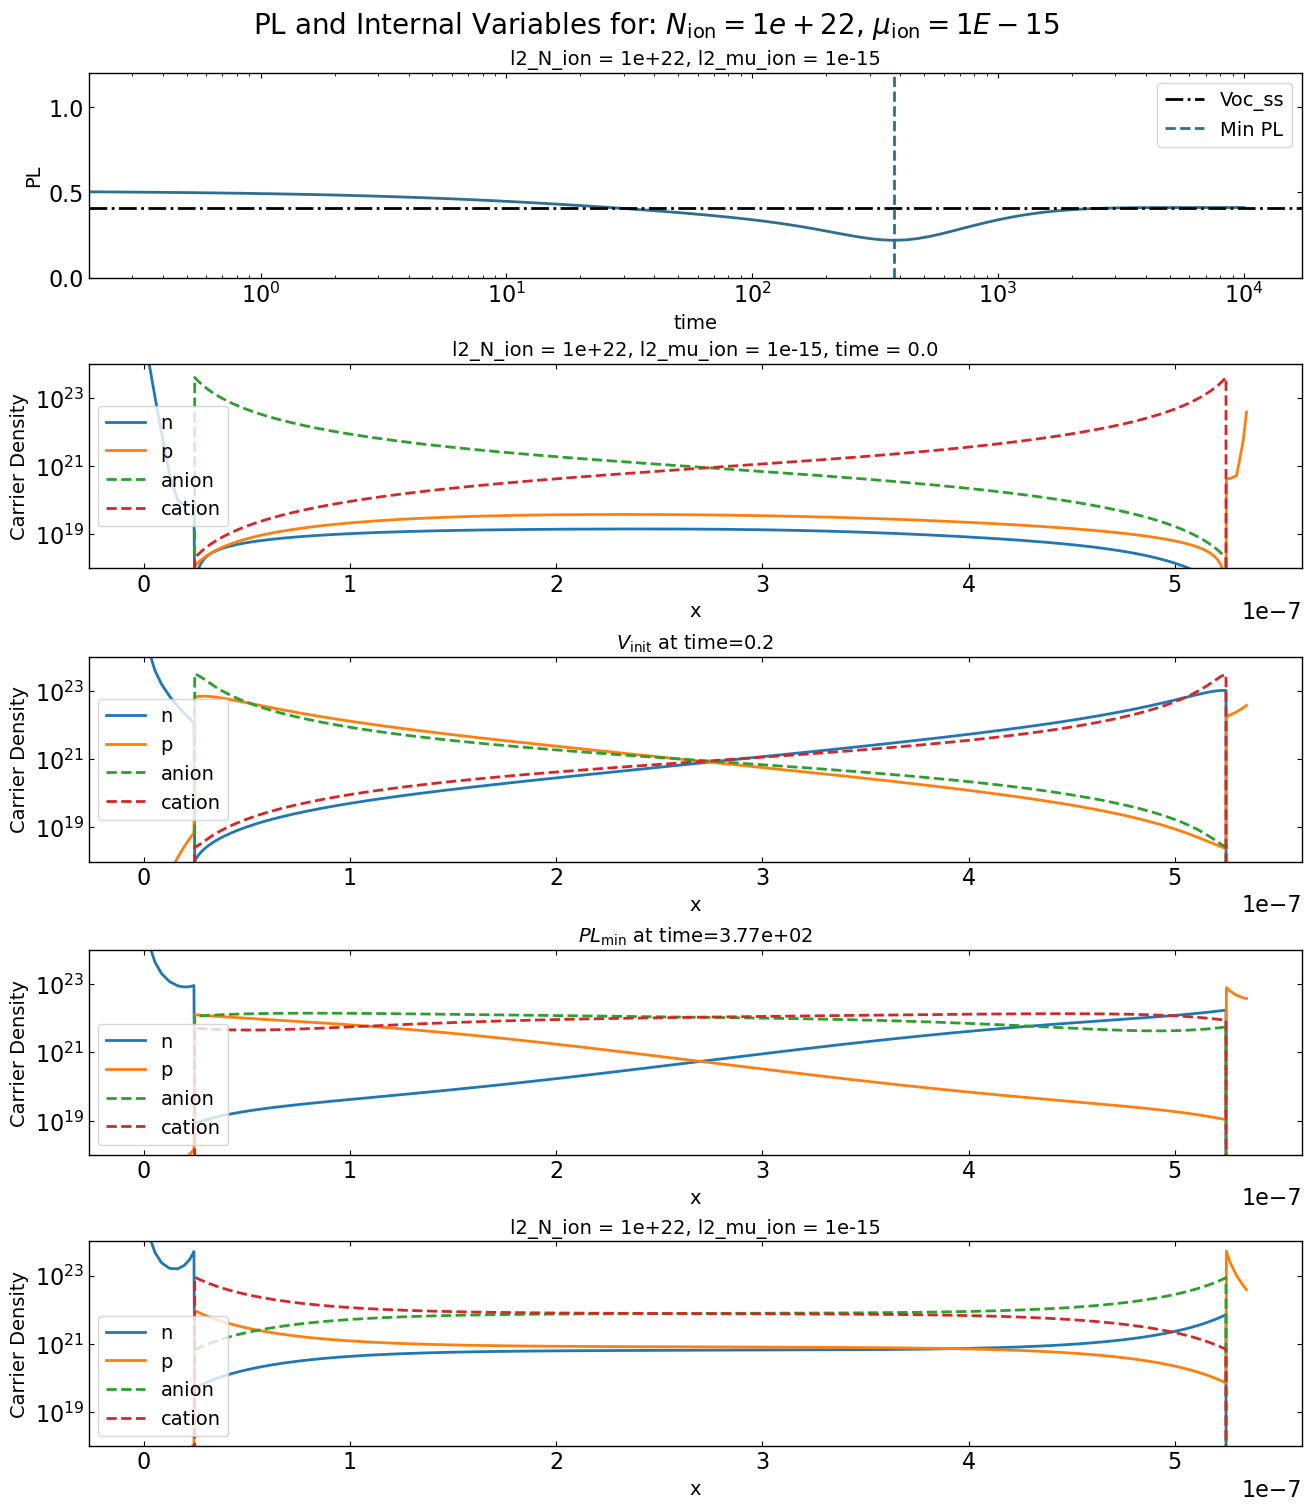

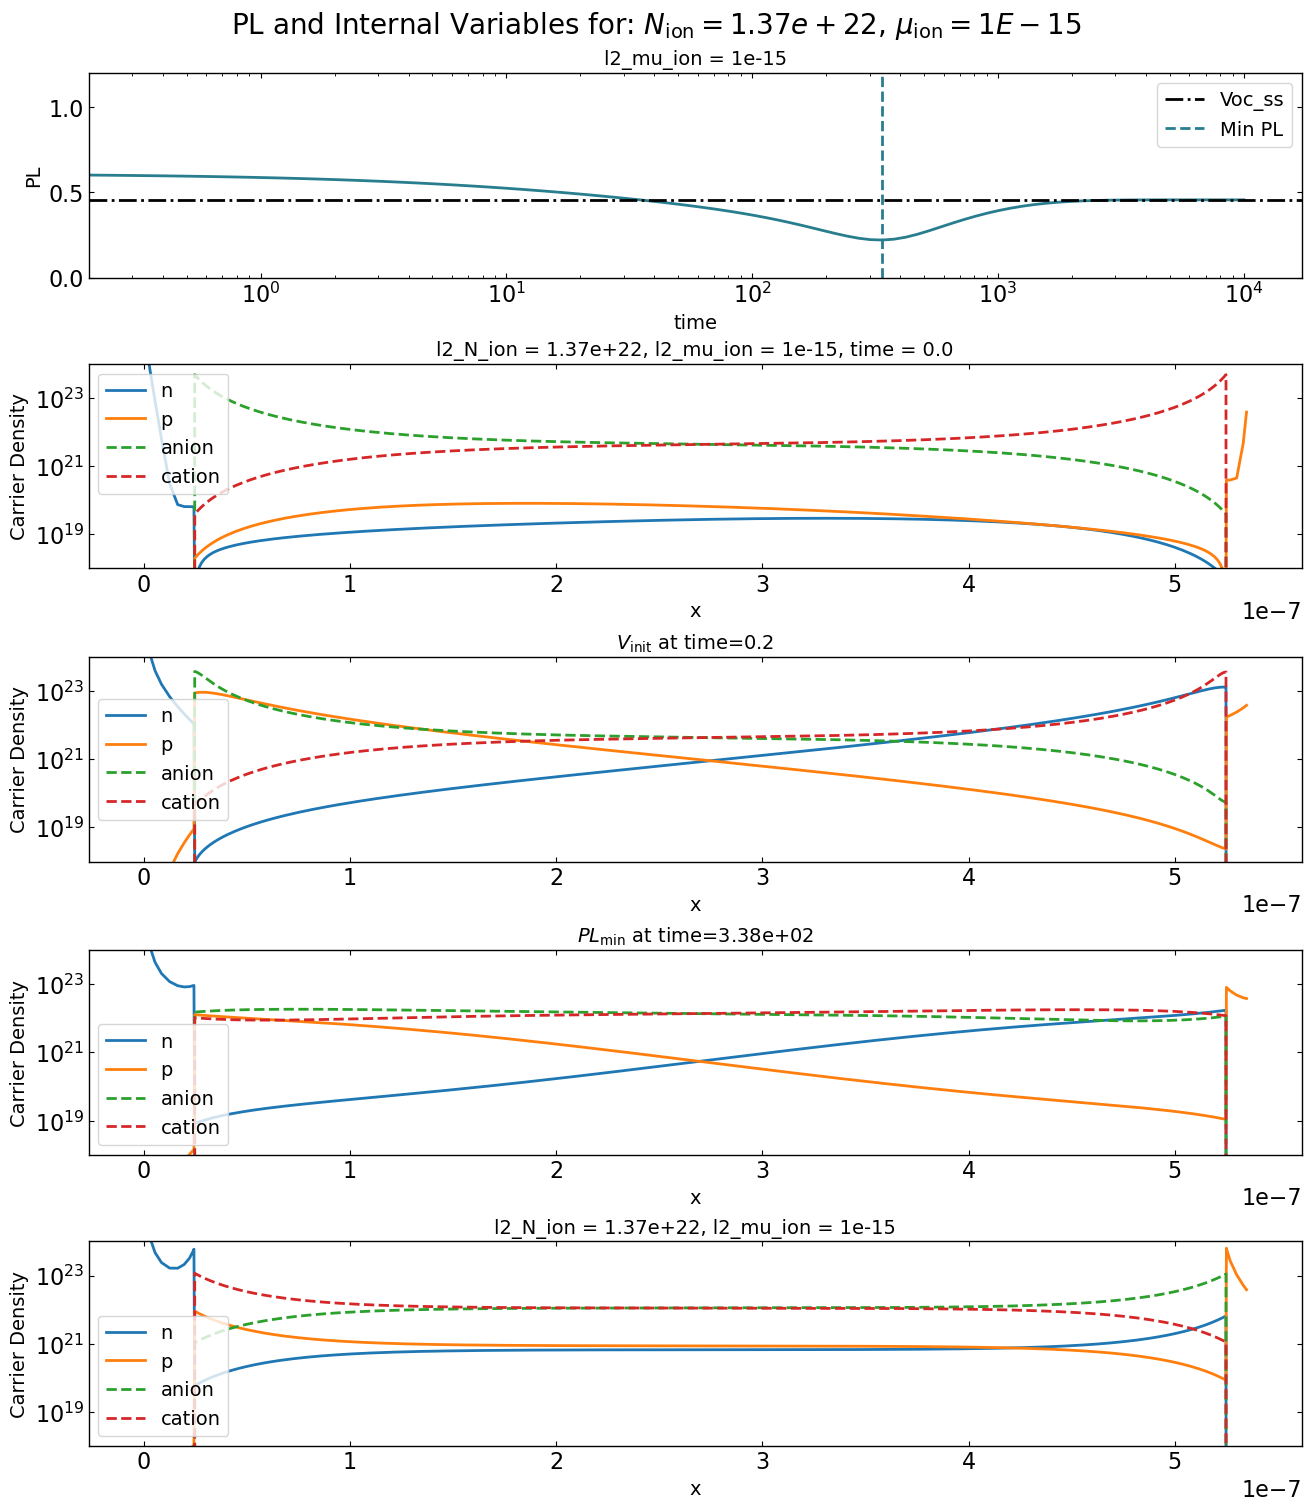

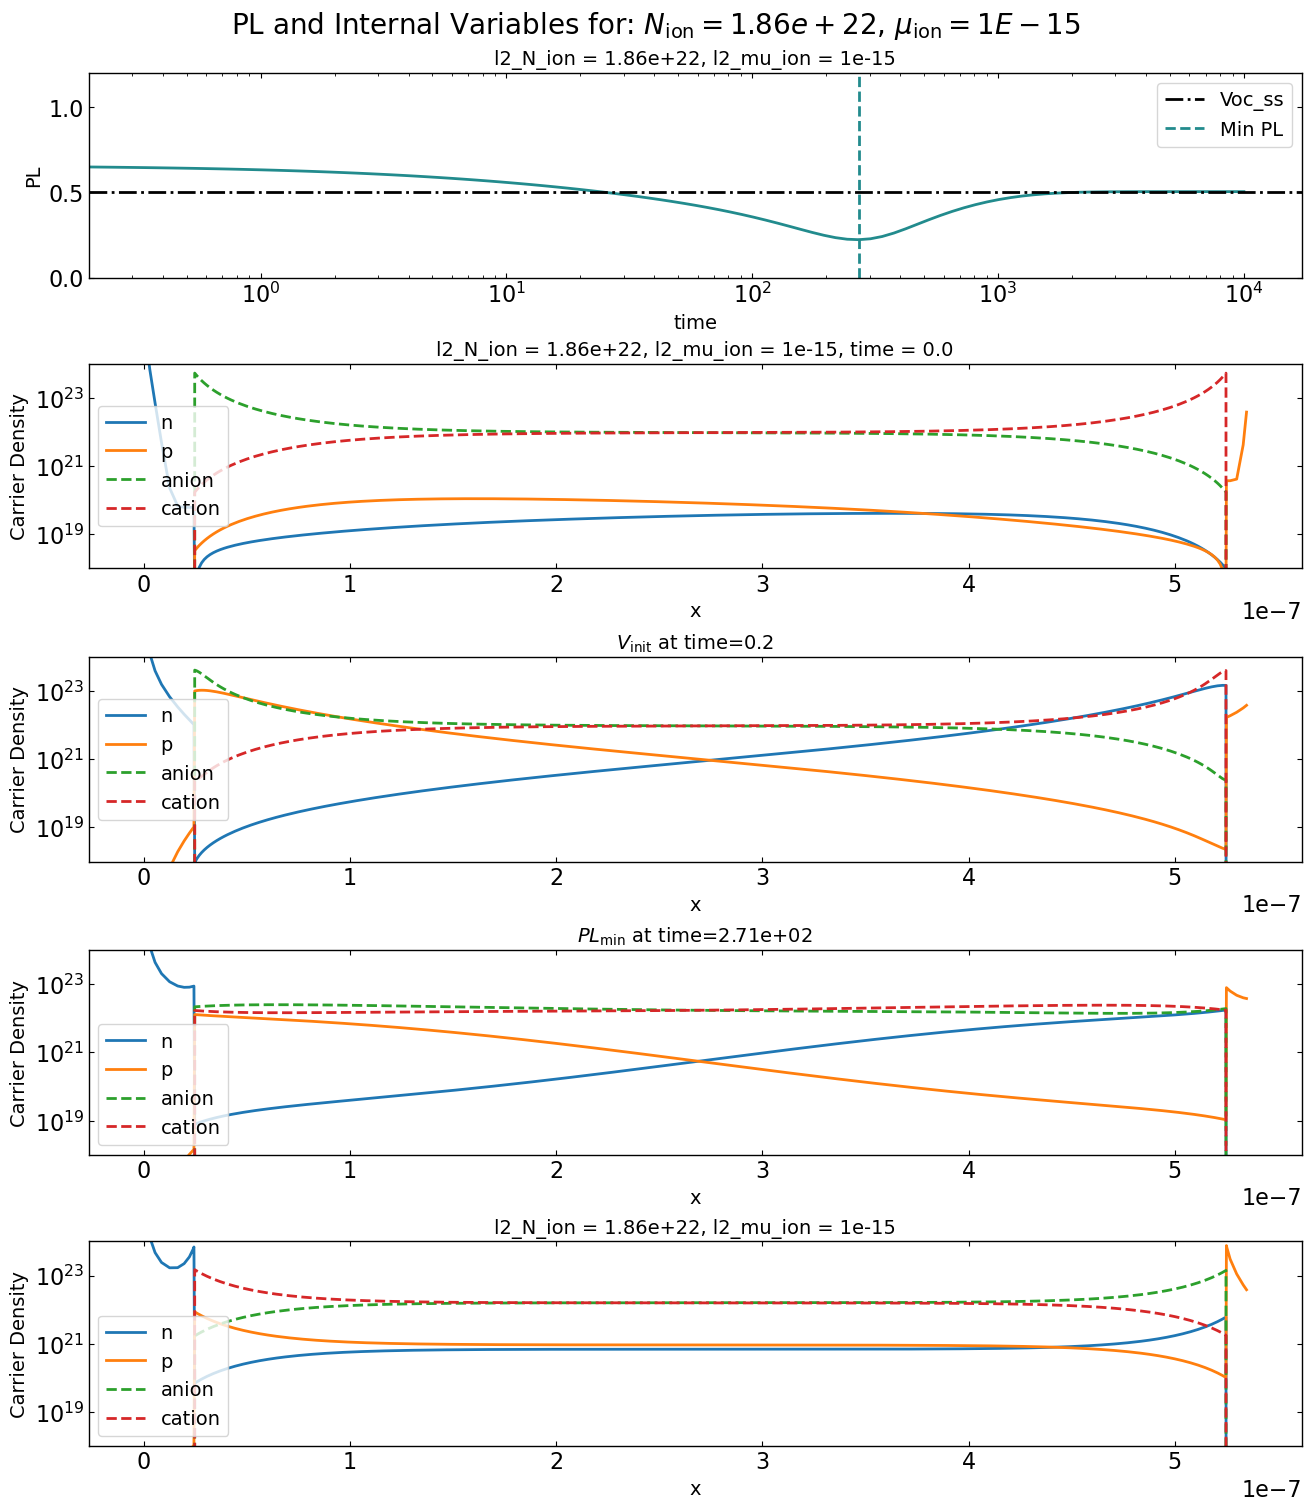

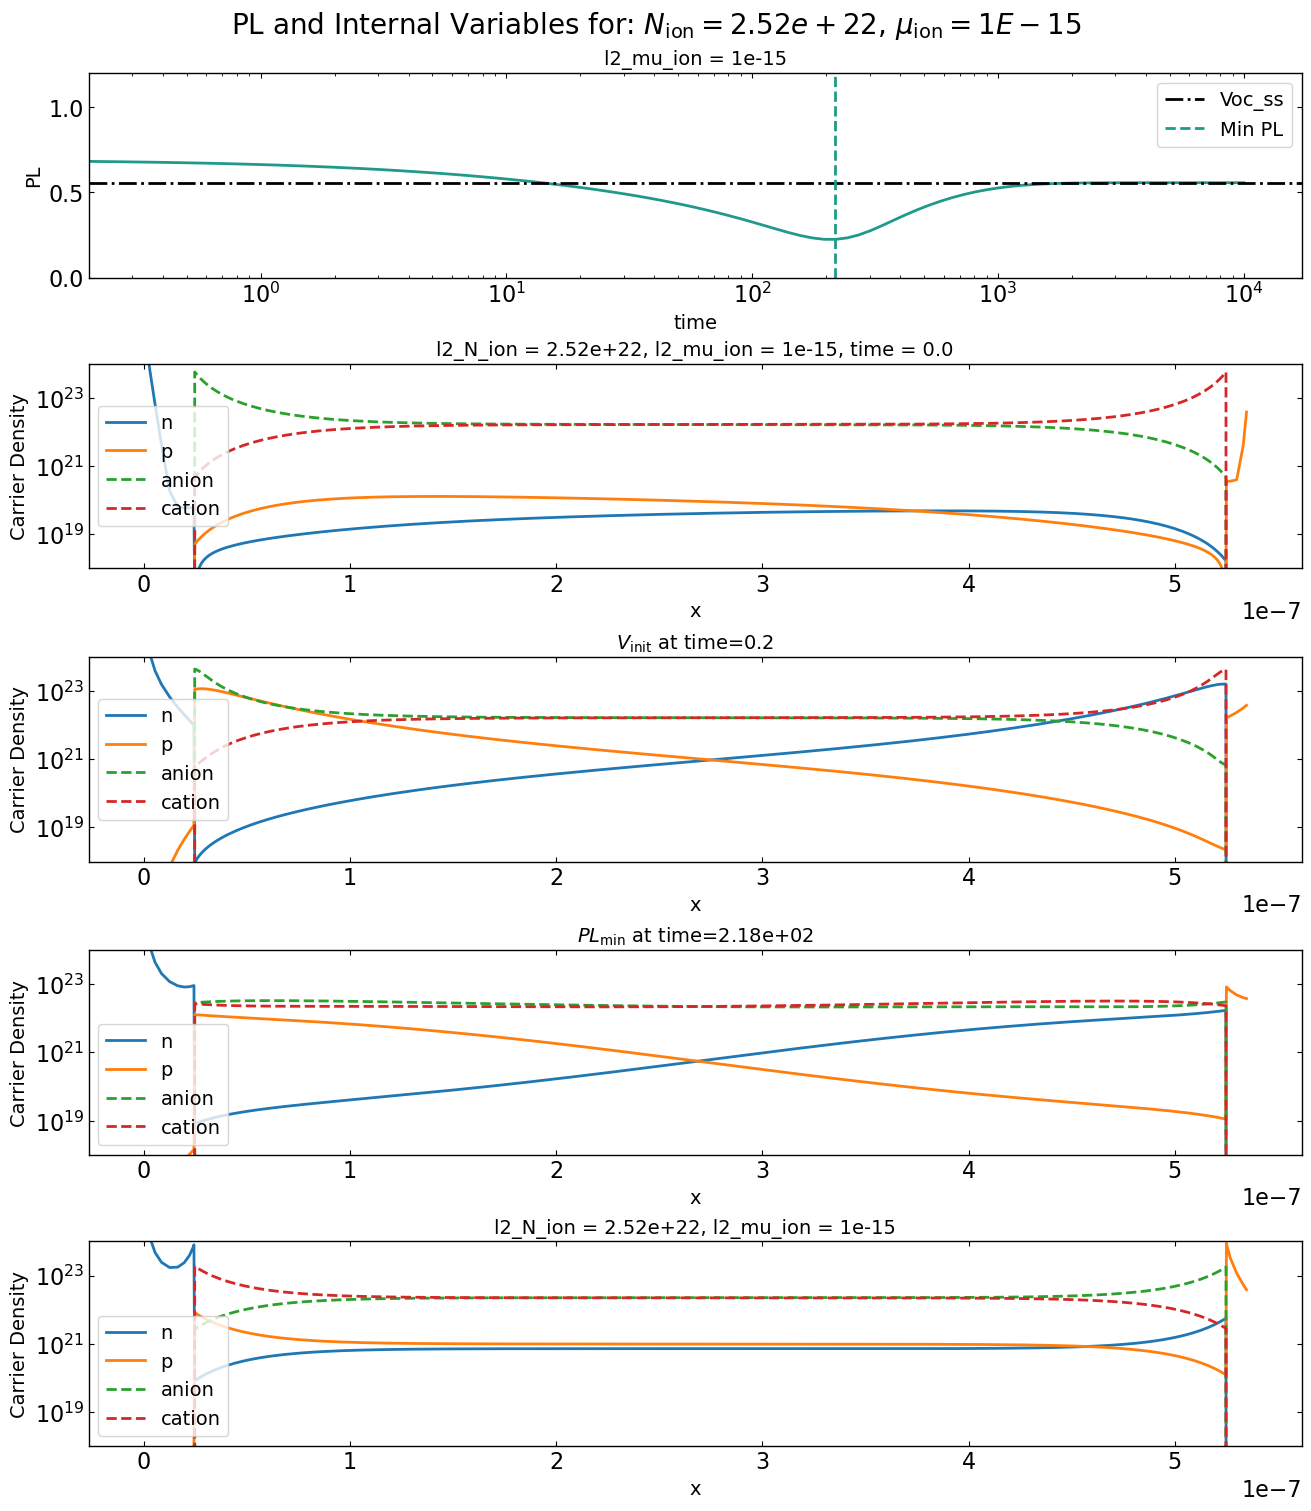

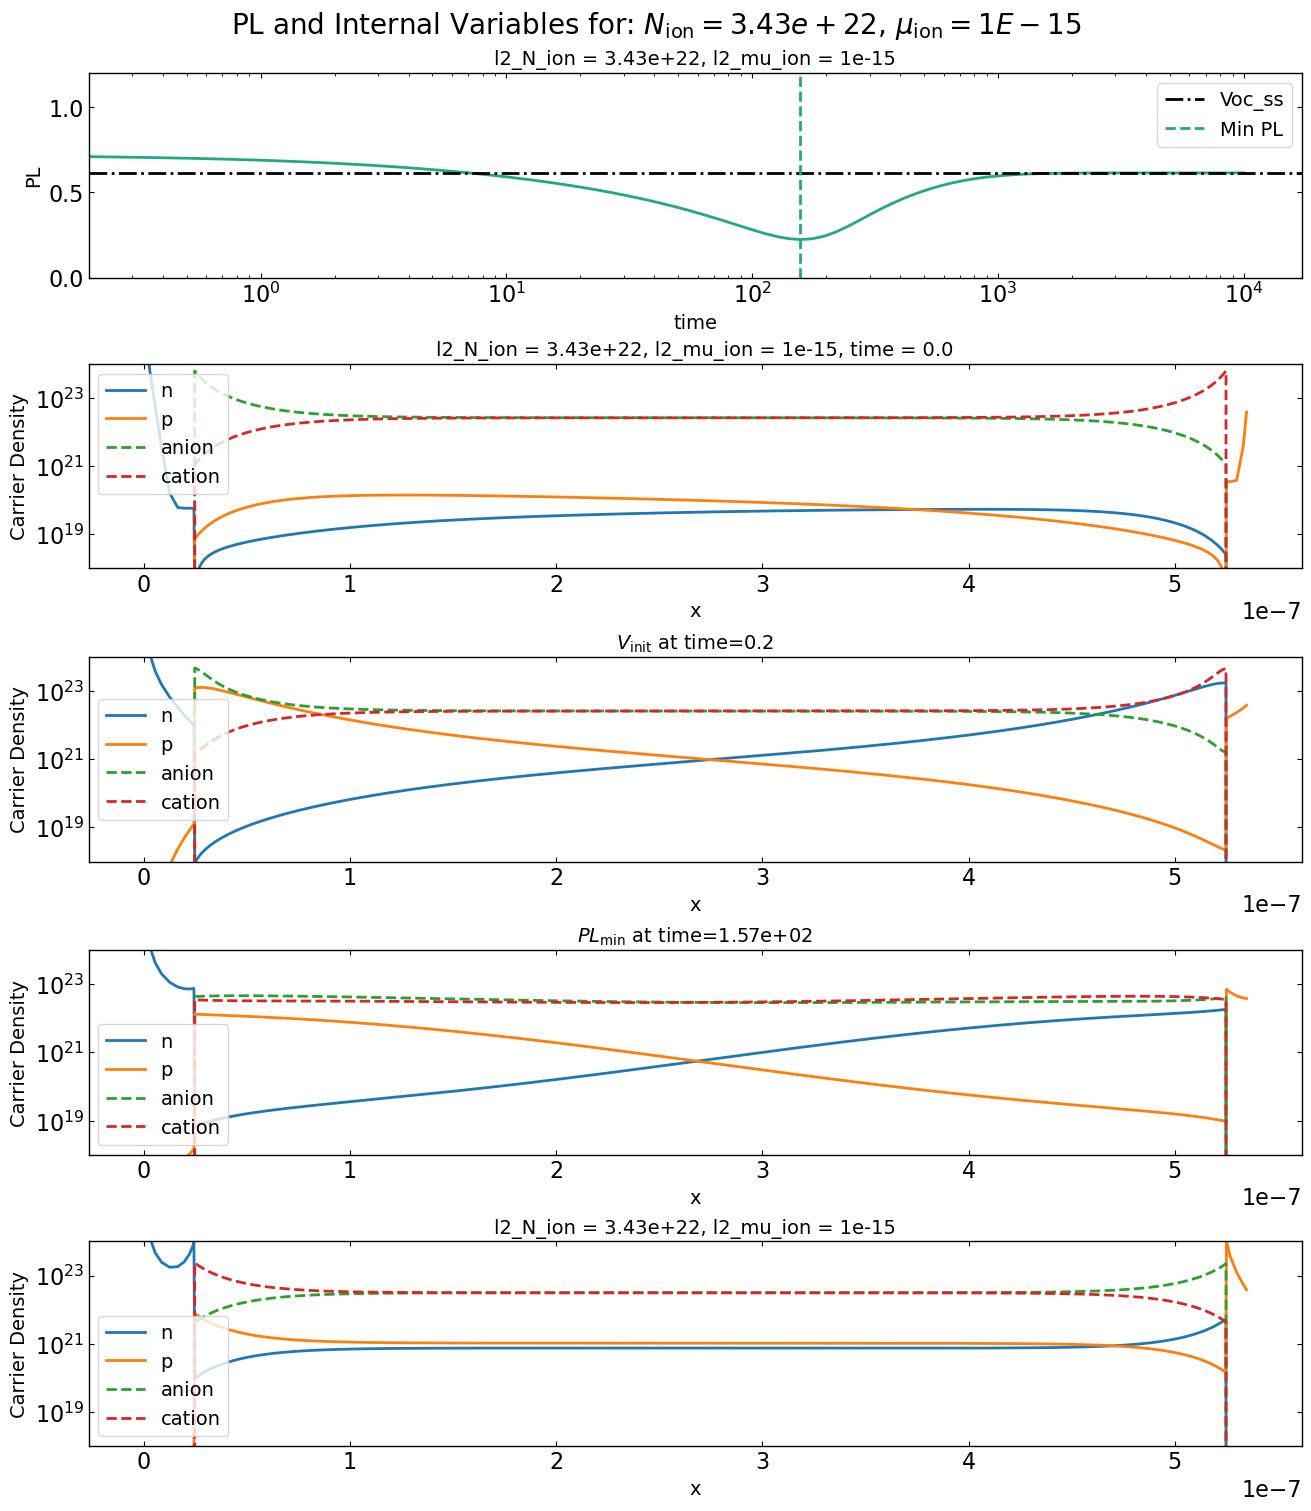

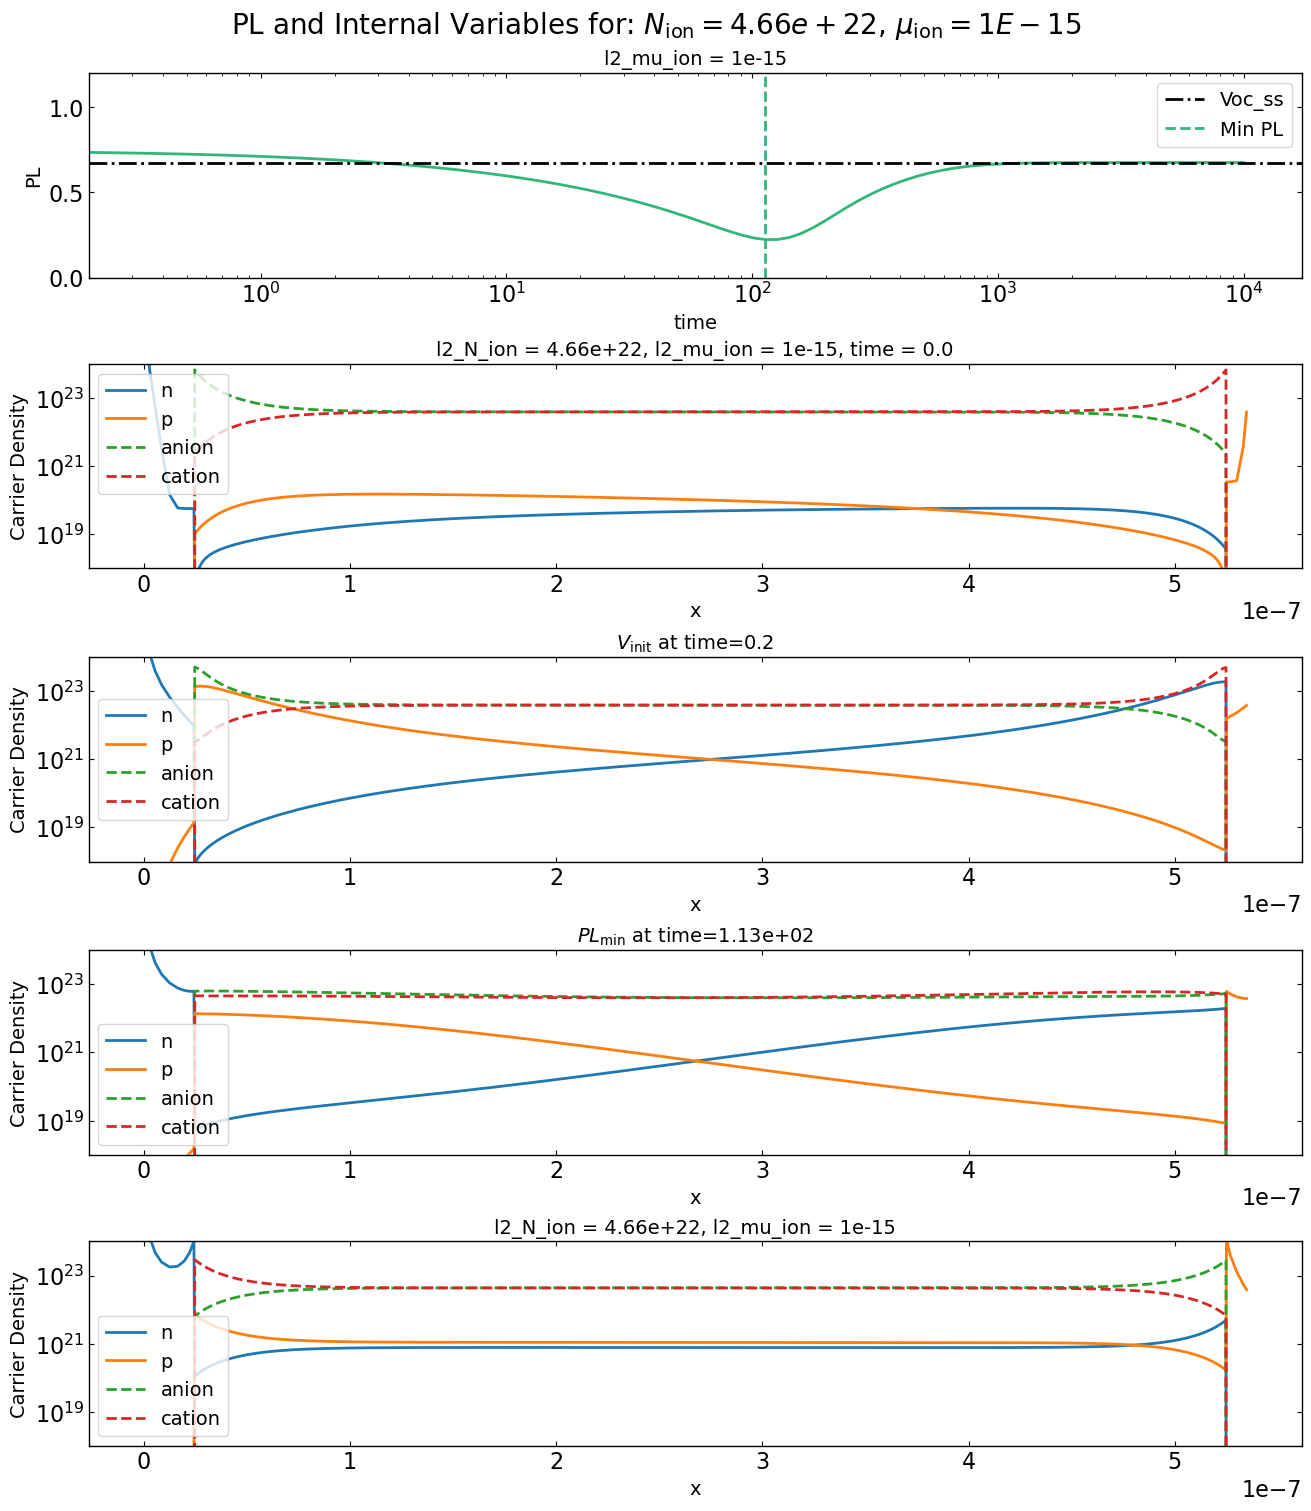

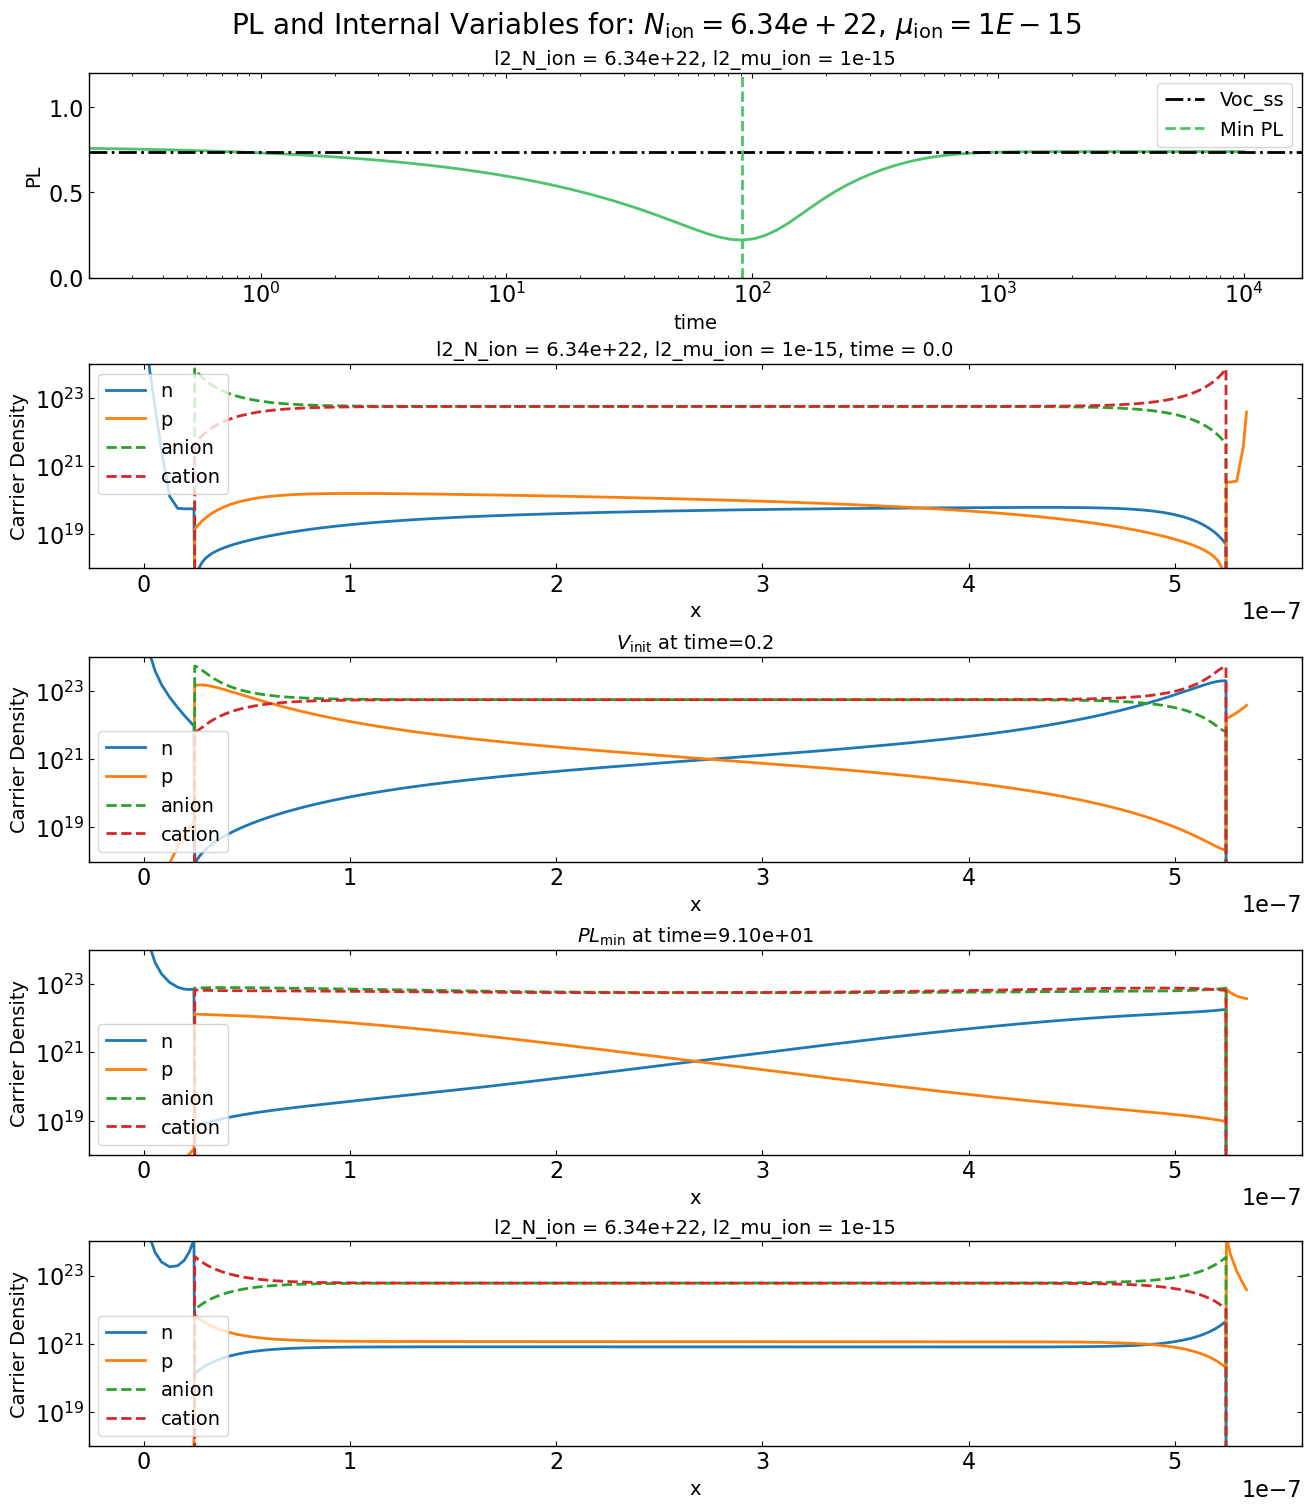

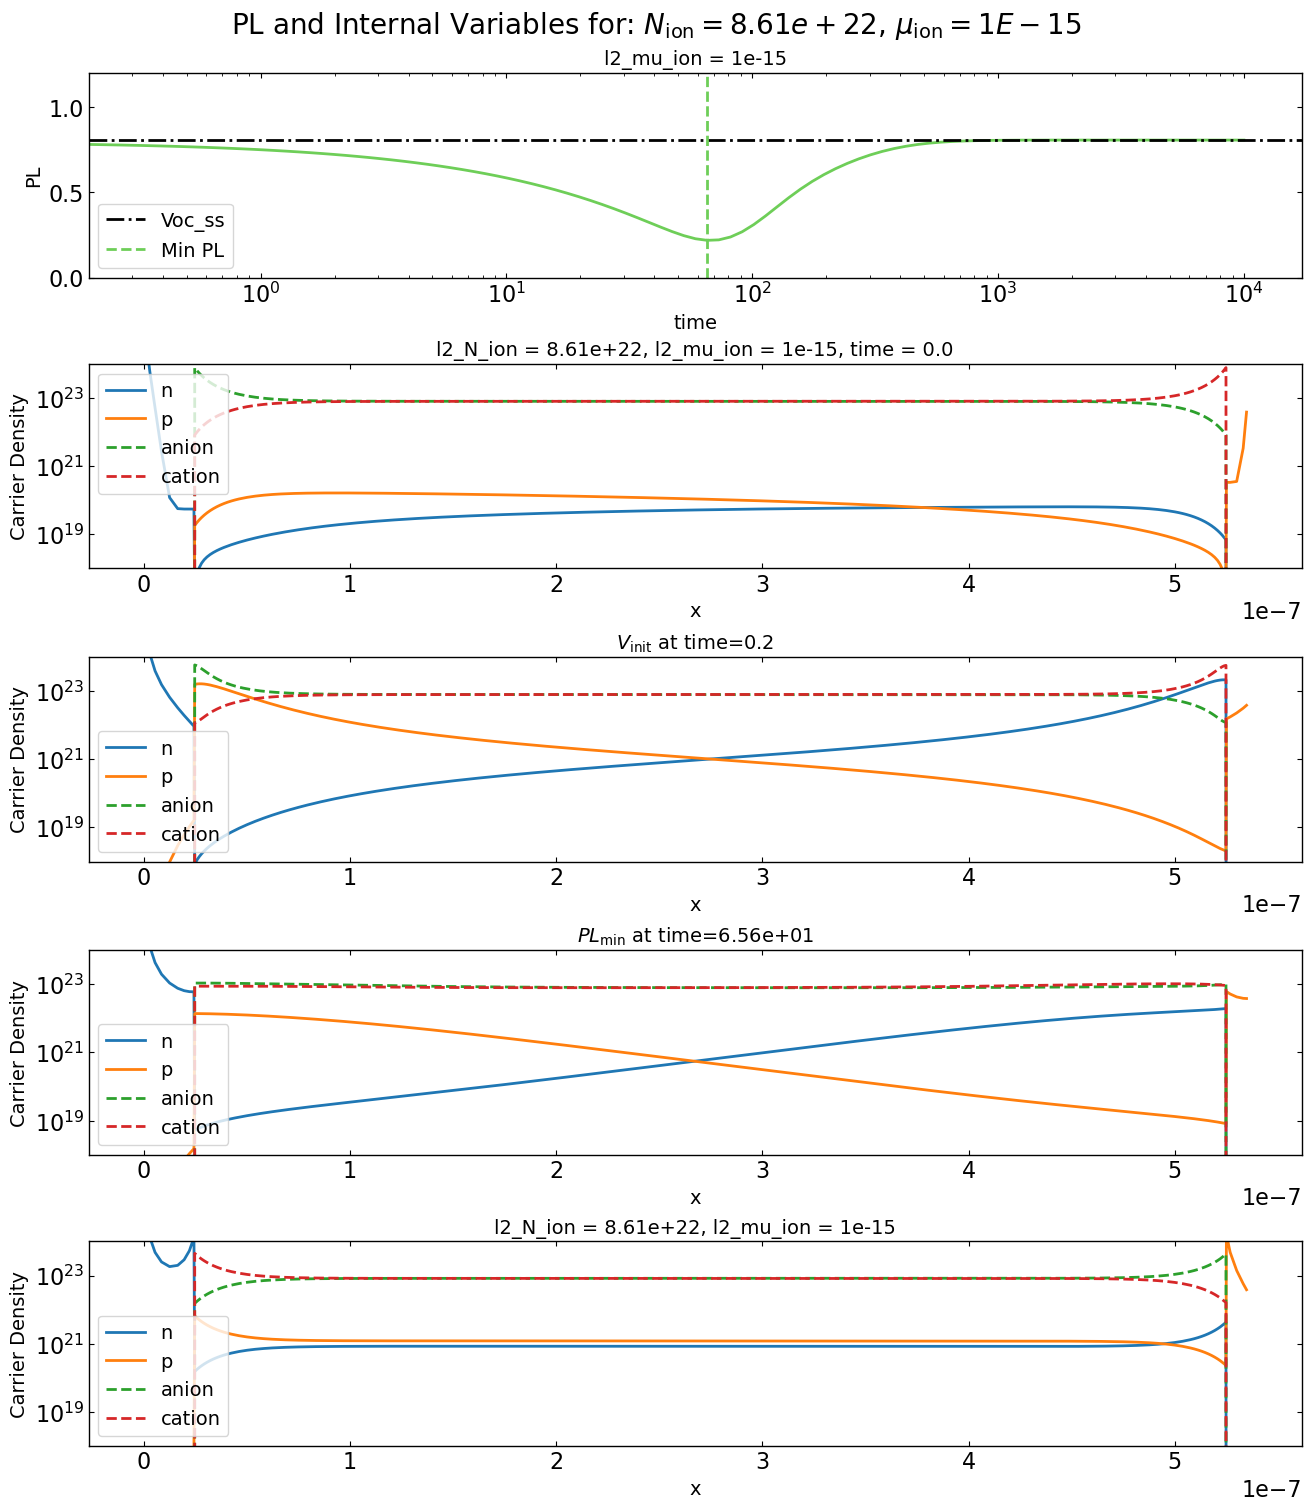

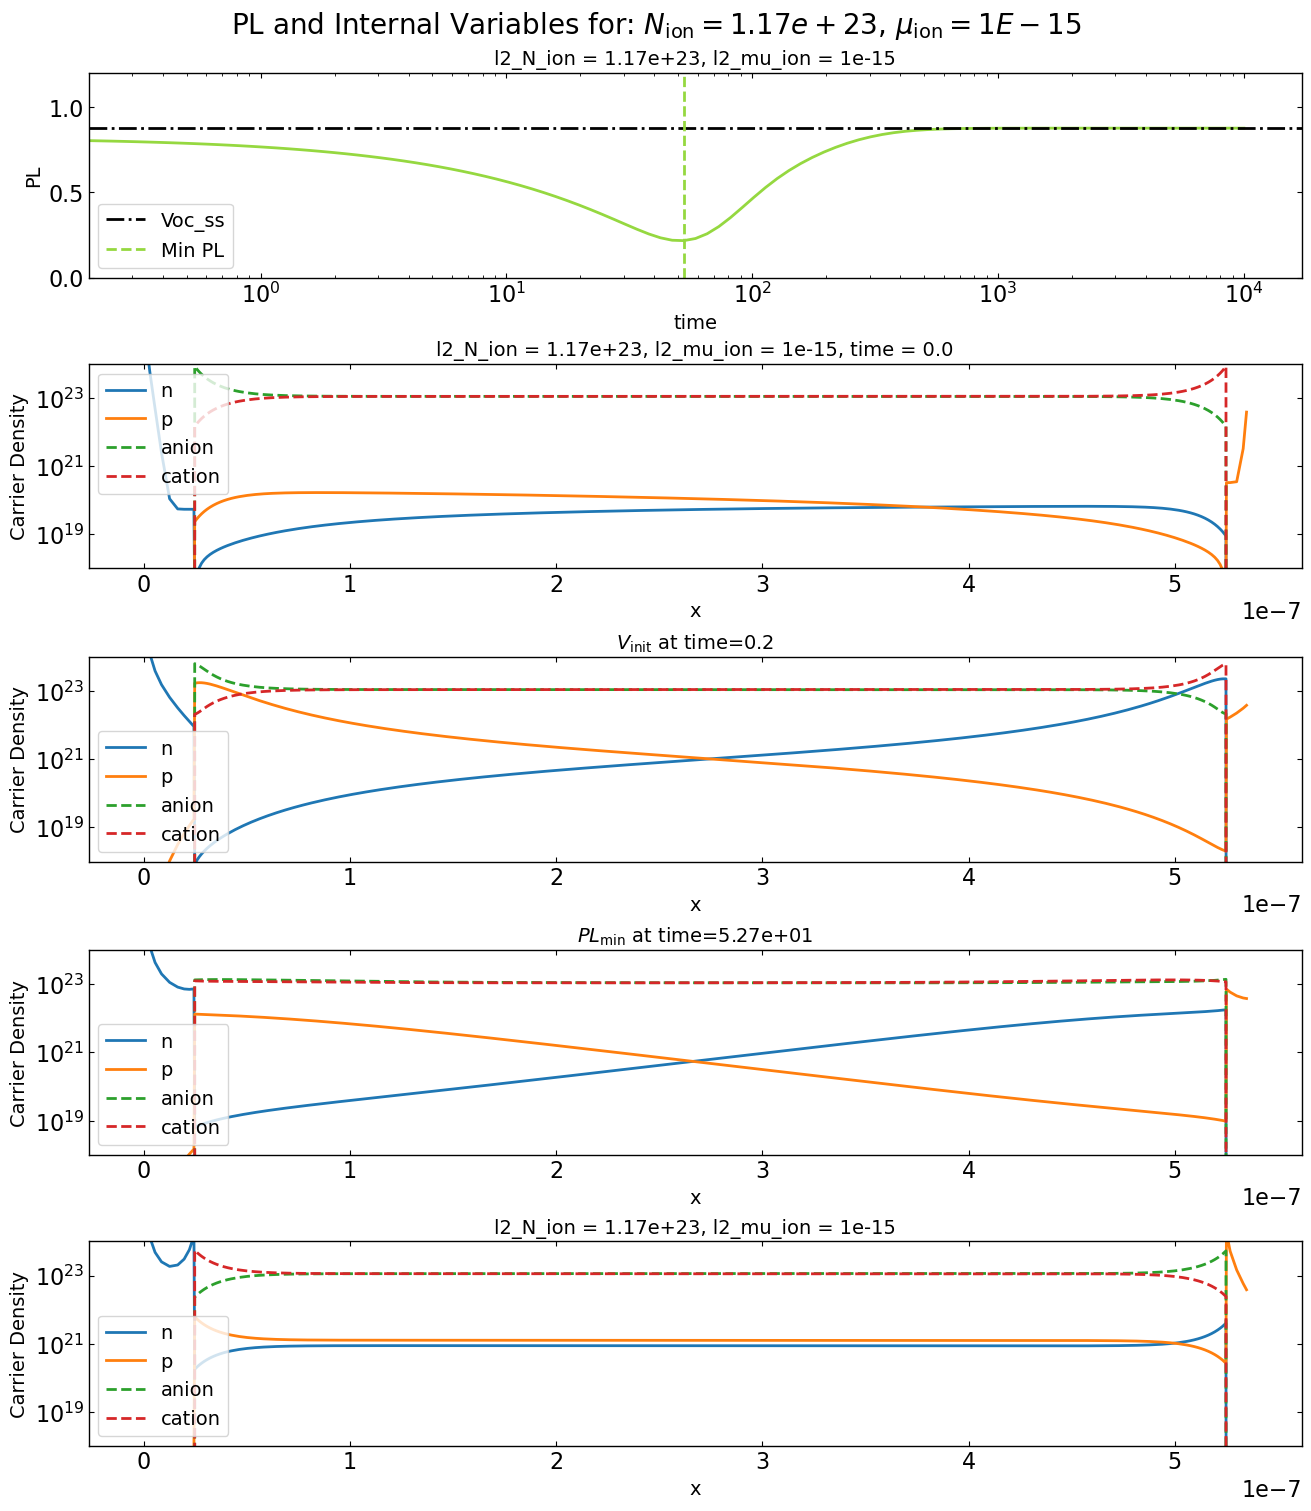

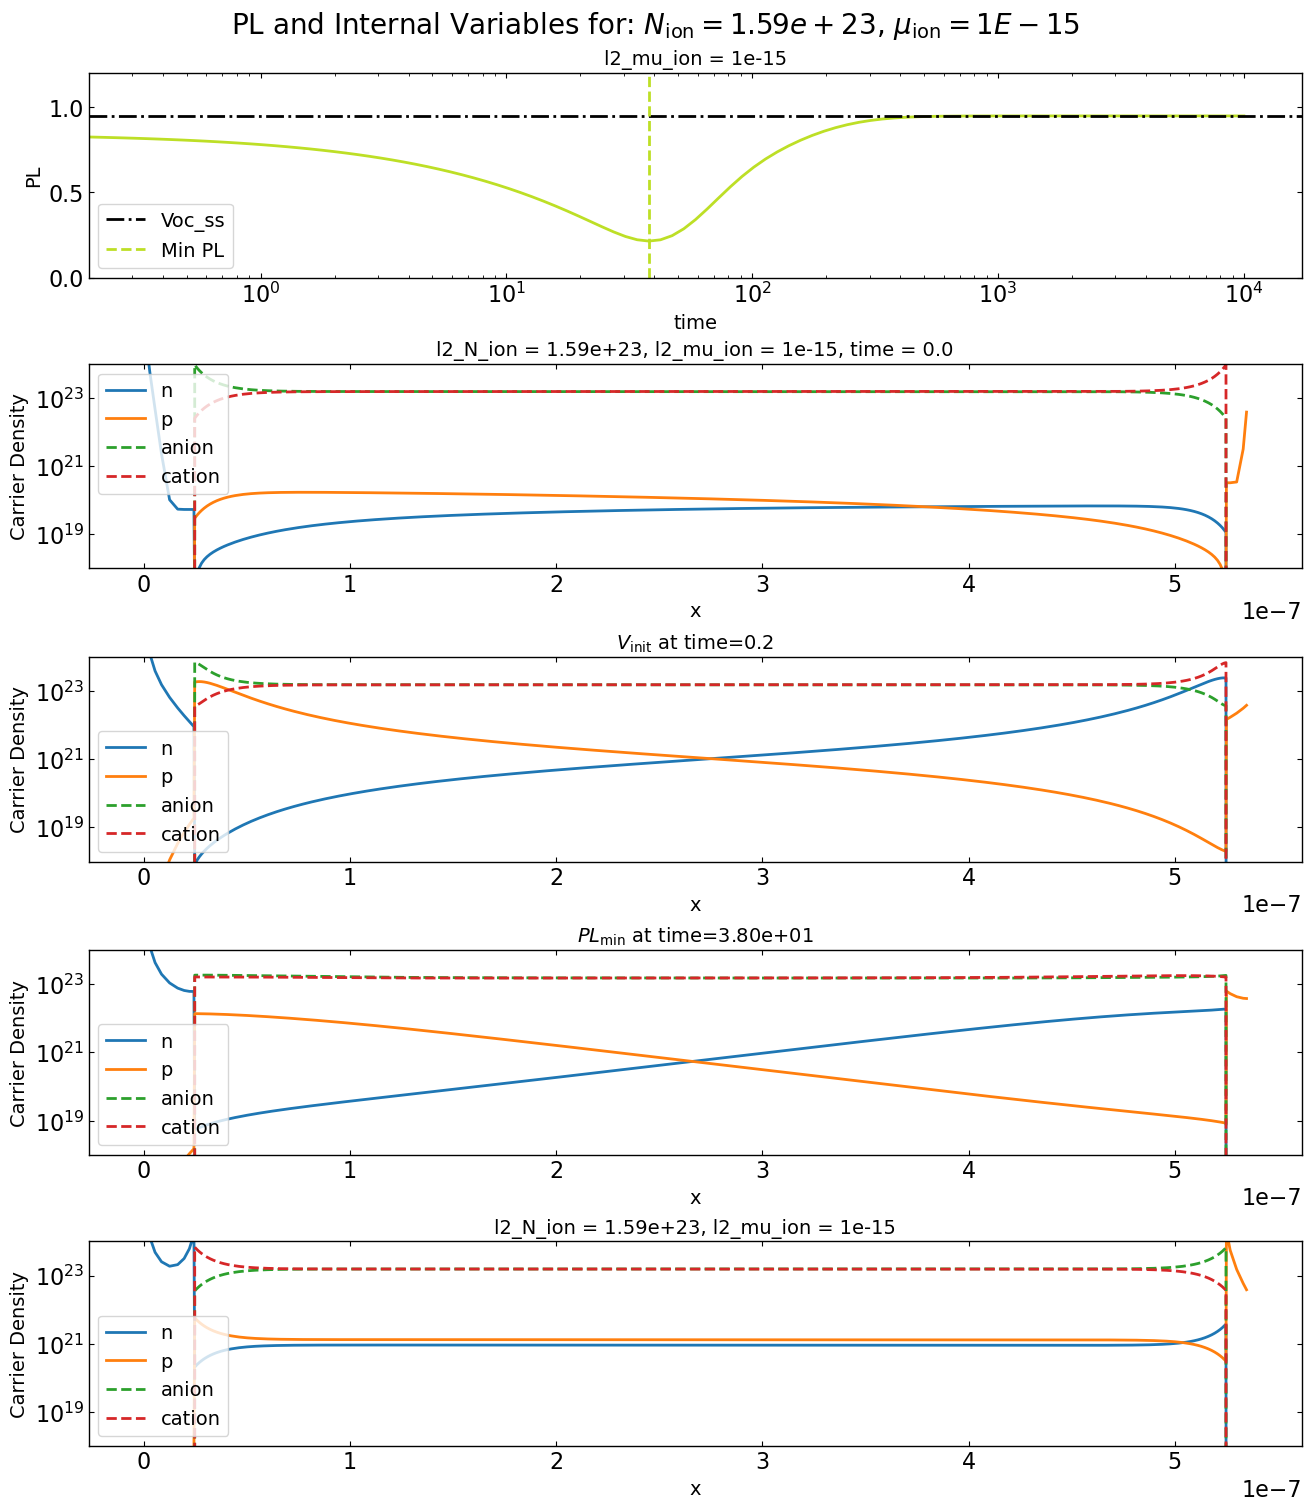

In [23]:
colormap = matplotlib.colormaps.get_cmap("viridis")
colors = colormap(np.linspace(0,0.9, len(zimt_run_dataset.l2_N_ion)))

for index, ion_density in enumerate(PL_dataset.l2_N_ion):
    
    # Extract PL data, Peak data, Voc_data
    PL_data = PL_dataset.PL.sel(l2_N_ion=ion_density).where(PL_data.time >= 0.2, drop=True)
    peak_data = PL_dataset.peak_time.sel(l2_N_ion=ion_density)
    transient_data = zimt_run_dataset.sel(l2_N_ion=ion_density).where(PL_data.time >= 0.2, drop=True)[["n", "p", "anion", "cation"]]
    Voc_ss_data = zimt_Voc_dataset.sel(l2_N_ion=ion_density).isel(time=0, drop=True)[["n", "p", "anion", "cation"]]
    
    # Set up the plot 
    fig, axes = plt.subplots(5, 1, layout='constrained', figsize=(13,15))
    
    # Plot the PL graph and the peak time if it has one at a reasonable value
    color = colors[index]
    PL_data.plot.line(x='time', ax=axes[0], xscale='log', color=color)
    axes[0].axhline(zimt_Voc_dataset.sel(l2_N_ion=ion_density).isel(time=0, drop=True).JdirL2.item(), color='black', linestyle='-.', label='Voc_ss')
    if peak_data.item() is not None and peak_data.item() < 5E3:
        axes[0].axvline(peak_data.item(), linestyle='dashed', color=color, label='Min PL')
    axes[0].set_xlim(0.2)
    axes[0].set_ylim(0, 1.2)
    axes[0].legend()
    
    # Plot the Vsc ss data
    Vsc_ss_data = zimt_run_dataset.sel(time=0).sel(l2_N_ion=ion_density)
    Vsc_ss_axes = axes[1]
    Vsc_ss_data.n.plot.line(x='x', ax=Vsc_ss_axes, label='n')
    Vsc_ss_data.p.plot.line(x='x', ax=Vsc_ss_axes, label='p')
    Vsc_ss_data.anion.plot.line(x='x', ax=Vsc_ss_axes, label='anion', linestyle='--')
    Vsc_ss_data.cation.plot.line(x='x', ax=Vsc_ss_axes, label='cation', linestyle='--')
    Vsc_ss_axes.set_yscale('log')
    Vsc_ss_axes.set_ylim(1E18, 1E24)
    Vsc_ss_axes.legend()
    Vsc_ss_axes.set_ylabel("Carrier Density")
    
    # Plot the electron, hole, cation, and anion densities for transient times
    transient_data_at_key_times = transient_data.sel(time=[0.2, peak_data.item()], method='nearest')
    for index, time in enumerate(transient_data_at_key_times.time):
            
        # Break out of the loop if time is None 
        if time.item() is None or time.item() > 5E3:
            continue
        
        index = index+2
        
        # Plot variables 
        transient_data_at_key_times.n.sel(time=time).plot.line(x='x', ax=axes[index], label='n')
        transient_data_at_key_times.p.sel(time=time).plot.line(x='x', ax=axes[index], label='p')
        transient_data_at_key_times.anion.sel(time=time).plot.line(x='x', ax=axes[index], label='anion', linestyle='--')
        transient_data_at_key_times.cation.sel(time=time).plot.line(x='x', ax=axes[index], label='cation', linestyle='--')
        
        # Once all plots have been placed, add a legend
        axes[index].legend()
        
        # Set axis configuration
        axes[index].set_yscale('log')
        axes[index].set_ylim(1E18, 1E24)
        axes[index].set_ylabel("Carrier Density")
        if time.item() == 0.2:
            axes[index].set_title("$V_\\text{init}$ at time=0.2")
        else:
            axes[index].set_title(f"$PL_\\text{{min}}$ at time={time.item():.2e}")
    
    # Do the same again for Voc 
    Voc_ss_axes = axes[4]
    Voc_ss_data.n.plot.line(x='x', ax=Voc_ss_axes, label='n')
    Voc_ss_data.p.plot.line(x='x', ax=Voc_ss_axes, label='p')
    Voc_ss_data.anion.plot.line(x='x', ax=Voc_ss_axes, label='anion', linestyle='--')
    Voc_ss_data.cation.plot.line(x='x', ax=Voc_ss_axes, label='cation', linestyle='--')
    Voc_ss_axes.set_yscale('log')
    Voc_ss_axes.set_ylim(1E18, 1E24)
    Voc_ss_axes.legend()
    Voc_ss_axes.set_ylabel("Carrier Density")
        
    
    # Set general figure captions 
    fig.suptitle(f"PL and Internal Variables for: $N_\\text{{ion}}={ion_density.item()}$, $\\mu_\\text{{ion}}=1E-15$", fontsize=20)
    

Error in PL: [5.54298917e-05 1.92093952e-05 4.51405585e-05 3.95778386e-05
 4.56166035e-05 2.90102160e-05 8.11846446e-05 6.93159604e-05
 8.92389335e-05 8.21477934e-05 8.31884540e-05 4.53578179e-05
 4.53739117e-05 8.10063644e-05 4.80110145e-05 4.31626743e-05]


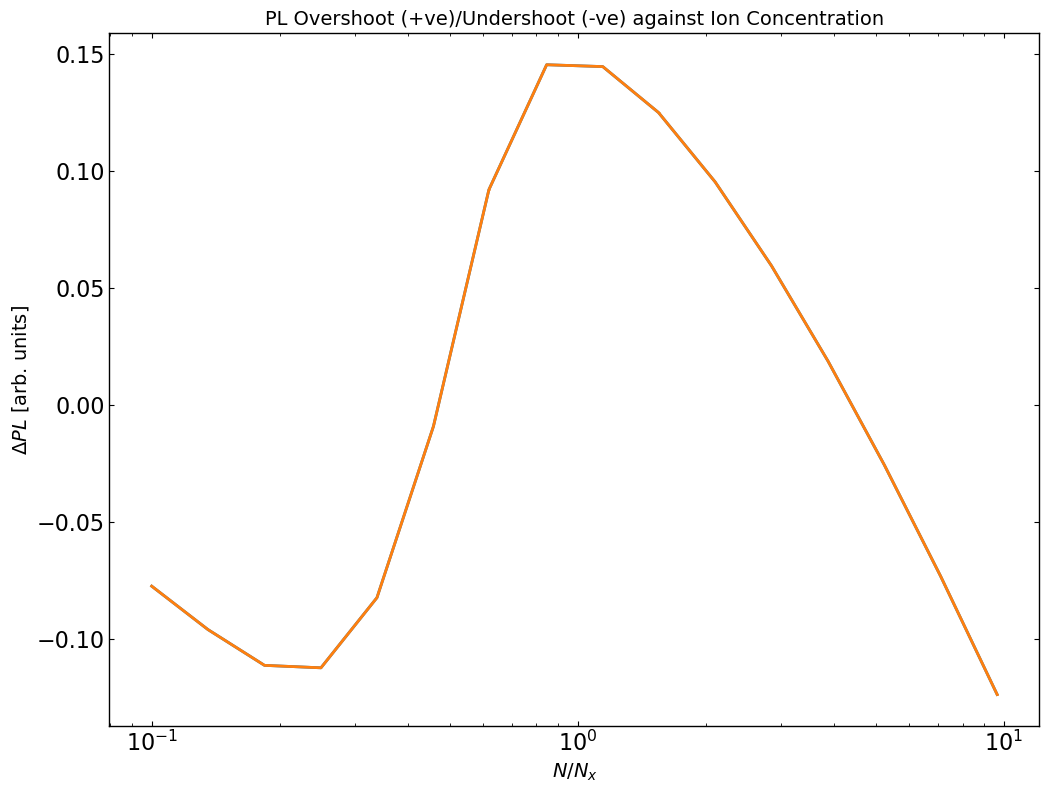

In [44]:
plt.figure(figsize=(12,9))

# Get critical ion densities and delta PL values 
delta_PL_values = [run["delta_PL"] for run in zimt_runs]
N_over_N_x_values = np.array([run["l2.N_cation"]/run["N_x"] for run in zimt_runs])
errJ_values = np.array([run['tj_data']['errJ'] for run in zimt_runs])

# Calculate the error in delta_PL by summing the variance of delta_PL at time = 0.2 and Voc steady state (assuming covariance is 0)
errJ_at_Voc_ini = errJ_values[:, 2]
errJ_at_Voc_ss = errJ_values[:, -1]
err_delta_PL = np.sqrt(errJ_at_Voc_ini**2 + errJ_at_Voc_ss**2)
print(f"Error in PL: {err_delta_PL}")

label = f"$N_\\text{{ion}} = {run["l2.N_cation"]}$"
plt.plot(N_over_N_x_values, delta_PL_values)
plt.errorbar(N_over_N_x_values, delta_PL_values, err_delta_PL)
plt.fill_between(N_over_N_x_values, delta_PL_values + err_delta_PL, delta_PL_values - err_delta_PL)

    
plt.xscale('log')
plt.xlabel("$N/N_x$")
plt.ylabel("$\\Delta PL$ [arb. units]")
plt.title("PL Overshoot (+ve)/Undershoot (-ve) against Ion Concentration")
# plt.legend(bbox_to_anchor=(1,1),ncols=2)
# plt.legend(ncols=1, bbox_to_anchor=(1,1))
# plt.savefig("PL response for varying ion mobility.pdf", format="pdf")
plt.show()

In [25]:
import xarray as xr
test_run = zimt_runs[0]
tj_data = test_run["tj_data"][:-1].set_index("t")
tj_data_dataset = xr.Dataset.from_dataframe(tj_data)
tj_data_dataset

<xarray.Dataset> Size: 26kB
Dimensions:        (t: 102)
Coordinates:
  * t              (t) float64 816B 0.0 0.1 0.2 ... 8.037e+03 8.965e+03 1e+04
Data variables: (12/31)
    Vext           (t) float64 816B 0.0 1.0 1.167 1.167 ... 1.199 1.199 1.199
    Jext           (t) float64 816B -217.2 -179.1 ... -0.003148 0.001108
    errJ           (t) float64 816B 3.609e-07 2.76e-05 ... 9.383e-06 2.566e-05
    Vint           (t) float64 816B 0.0 1.0 1.167 1.167 ... 1.199 1.199 1.199
    Jint           (t) float64 816B -217.2 -179.1 ... -0.003148 0.001108
    G_frac         (t) float64 816B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    ...             ...
    JminLeft       (t) float64 816B 9.037e-14 3.443e-09 ... -1.125e-06
    JminRight      (t) float64 816B 1.445 1.44 1.437 1.437 ... 1.429 1.429 1.429
    JShunt         (t) float64 816B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Jnion          (t) float64 816B 0.0 6.05e-08 ... 5.503e-12 1.619e-12
    Jpion          (t) float64 816B 0.0 3.862e-07 ... 5.268e-12 1.442e-12
    JD             (t) float64 816B 0.0 0.003166 ... -7.168e-13 5.656e-14

In [26]:
test_run["tj_data"].tail(1)

,t,Vext,Jext,errJ,Vint,Jint,G_frac,QFLSL1,QFLSL2,QFLSL3,...,JintElecL1L2,JintElecL2L3,JintHolesL1L2,JintHolesL2L3,JminLeft,JminRight,JShunt,Jnion,Jpion,JD
102,0.0,1.199219,-0.00085,0.000003,1.199219,-0.00085,1.0,1.118271,1.209755,1.072042,...,136.353553,34.075205,136.35355,34.075203,-0.000001,1.428809,0.0,0.0,0.0,0.0


In [27]:
# Get the varFile data from the example 
var_data = test_run["var_file"][:-252].set_index(["time", "x"])
# len(var_data.index.levels[1])
var_data_xarray = xr.Dataset.from_dataframe(var_data)

In [28]:
test_run["var_file"].set_index(["time", "x"])[-252:]

V      Evac        Ec        Ev      phin      phip  \
time x                                                                          
0.0  0.000000e+00 -0.024609  0.000000 -4.000000 -5.900000 -4.050000 -4.050000   
     1.272503e-10 -0.040290  0.015681 -3.984319 -5.884319 -4.050000 -5.020565   
     1.067510e-09 -0.087591  0.062981 -3.937019 -5.837019 -4.050000 -5.069323   
     2.898885e-09 -0.125778  0.101169 -3.898831 -5.798831 -4.050000 -5.106573   
     5.454776e-09 -0.152542  0.127933 -3.872067 -5.772067 -4.050001 -5.135080   
...                     ...       ...       ...       ...       ...       ...   
     5.252195e-07 -0.015614 -0.008995 -2.258995 -5.408995 -4.043408 -5.249218   
     5.268412e-07 -0.005146 -0.019463 -2.269463 -5.419463 -4.057591 -5.249218   
     5.300000e-07  0.009619 -0.034229 -2.284229 -5.434229 -4.081779 -5.249218   
     5.331588e-07  0.020227 -0.044837 -2.294837 -5.444837 -4.115711 -5.249219   
     5.347805e-07  0.024609 -0.049219 -2.299219 -5.449219 -5.249219 -5.249219   

                              n             p   ND   NA  ...  BulkSRHp  \
time x                                                   ...             
0.0  0.000000e+00  6.995027e+25  1.242476e-05  0.0  0.0  ...       0.0   
     1.272503e-10  3.774925e+25  8.768633e+11  0.0  0.0  ...       0.0   
     1.067510e-09  5.872753e+24  3.836663e+13  0.0  0.0  ...       0.0   
     2.898885e-09  1.307548e+24  7.459392e+14  0.0  0.0  ...       0.0   
     5.454776e-09  4.562616e+23  6.560368e+15  0.0  0.0  ...       0.0   
...                         ...           ...  ...  ...  ...       ...   
     5.252195e-07  3.279309e-05  1.863921e+23  0.0  0.0  ...       0.0   
     5.268412e-07  2.833417e-05  1.234816e+23  0.0  0.0  ...       0.0   
     5.300000e-07  1.955893e-05  6.908034e+22  0.0  0.0  ...       0.0   
     5.331588e-07  7.814373e-06  4.551347e+22  0.0  0.0  ...       0.0   
     5.347805e-07  4.011851e-25  3.830695e+22  0.0  0.0  ...       0.0   

                   IntSRHn  IntSRHp        Jn            Jp      Jint  Jnion  \
time x                                                                         
0.0  0.000000e+00      0.0      0.0 -0.000842 -1.124924e-06 -0.000843    0.0   
     1.272503e-10      0.0      0.0 -0.000842 -1.075056e-06 -0.000843    0.0   
     1.067510e-09      0.0      0.0 -0.000842 -4.139089e-07 -0.000843    0.0   
     2.898885e-09      0.0      0.0 -0.000846  3.580265e-06 -0.000843    0.0   
     5.454776e-09      0.0      0.0 -0.000861  1.855175e-05 -0.000843    0.0   
...                    ...      ...       ...           ...       ...    ...   
     5.252195e-07      0.0      0.0  1.428809 -1.429663e+00 -0.000854    0.0   
     5.268412e-07      0.0      0.0  1.428809 -1.429663e+00 -0.000854    0.0   
     5.300000e-07      0.0      0.0  1.428809 -1.429663e+00 -0.000854    0.0   
     5.331588e-07      0.0      0.0  1.428809 -1.429663e+00 -0.000854    0.0   
     5.347805e-07      0.0      0.0  1.428809 -1.429663e+00 -0.000854    0.0   

                   Jpion   JD  lid  
time x                              
0.0  0.000000e+00    0.0  0.0    1  
     1.272503e-10    0.0  0.0    1  
     1.067510e-09    0.0  0.0    1  
     2.898885e-09    0.0  0.0    1  
     5.454776e-09    0.0  0.0    1  
...                  ...  ...  ...  
     5.252195e-07    0.0  0.0    3  
     5.268412e-07    0.0  0.0    3  
     5.300000e-07    0.0  0.0    3  
     5.331588e-07    0.0  0.0    3  
     5.347805e-07    0.0  0.0    3  

[252 rows x 30 columns]

TypeError: pcolormesh() takes 1 or 3 positional arguments but 2 were given

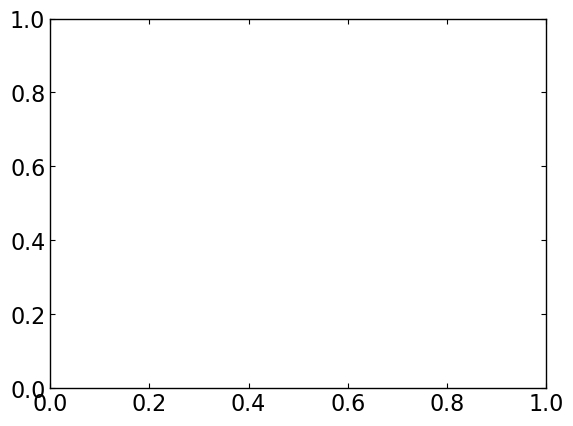

In [29]:
electron_density_data = var_data_xarray.n
pcm = plt.pcolormesh(electron_density_data.coords, electron_density_data, cmap='viridis', norm=matplotlib.colors.LogNorm(vmin=1E20, vmax=1E25))
plt.title("Electron Density within the solar cell device")
plt.colorbar(pcm)
plt.show()

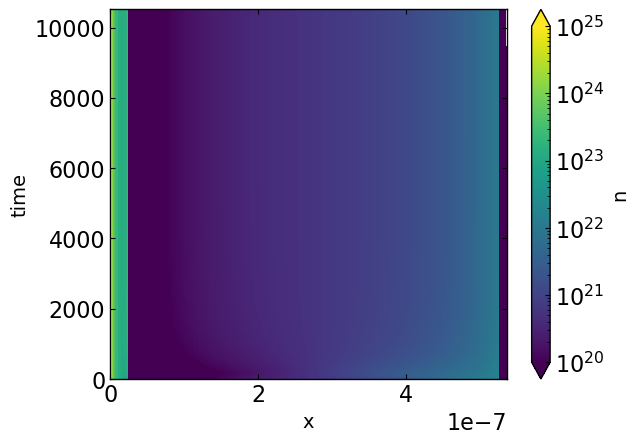

In [ ]:
electron_density_data.plot.pcolormesh(norm=matplotlib.colors.LogNorm(vmin=1E20, vmax=1E25))

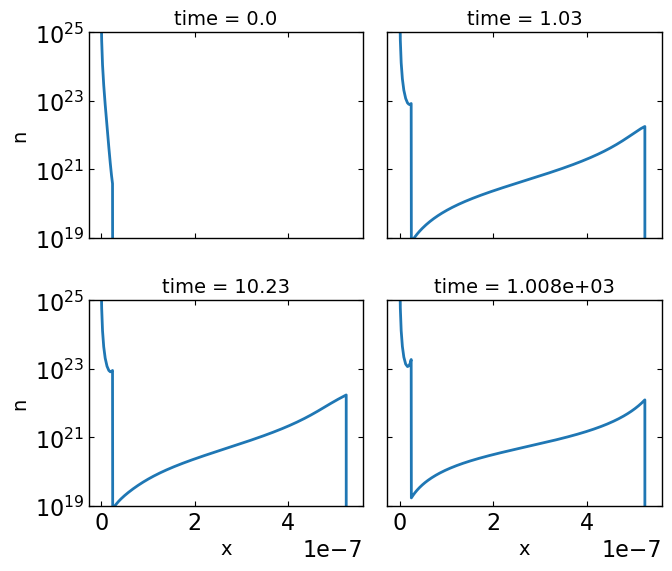

In [ ]:
electron_density_data.sel(time=[0, 1, 10, 1000], method='nearest').plot(x='x', col='time', col_wrap=2, yscale='log', ylim=[1E19, 1E25])

In [ ]:
tj_data_dataset = tj_data_dataset.rename({"t":"time"})

In [ ]:
tj_data_dataset.Jint.sel(time=0)

<xarray.DataArray 'Jint' ()> Size: 8B
array(-217.184457)
Coordinates:
    time     float64 8B 0.0

In [ ]:
var_data_xarray.Jint.sel(time=0)

<xarray.DataArray 'Jint' (x: 252)> Size: 2kB
array([-217.1844575, -217.1844575, -217.1844575, -217.1844575,
       -217.1844575, -217.1844575, -217.1844575, -217.1844575,
       -217.1844575, -217.1844575, -217.1844575, -217.1844575,
       -217.1844575, -217.1844575, -217.1844575, -217.1844575,
       -217.1844575, -217.1844575, -217.1844575, -217.1844575,
       -217.1844575, -217.1844575, -217.1844575, -217.1844575,
       -217.1844575, -217.1844575, -217.1844575, -217.1844575,
       -217.1844575, -217.1844575, -217.1844575, -217.1844575,
       -217.1844575, -217.1844575, -217.1844575, -217.1844575,
       -217.1844575, -217.1844575, -217.1844575, -217.1844574,
       -217.1844574, -217.1844574, -217.1844574, -217.1844574,
       -217.1844574, -217.1844574, -217.1844574, -217.1844574,
       -217.1844574, -217.1844574, -217.1844574, -217.1844574,
       -217.1844574, -217.1844574, -217.1844574, -217.1844574,
       -217.1844574, -217.1844574, -217.1844574, -217.1844574,
       -217.1844574, -217.1844574, -217.1844574, -217.1844574,
       -217.1844574, -217.1844574, -217.1844574, -217.1844574,
       -217.1844574, -217.1844574, -217.1844573, -217.1844573,
       -217.1844573, -217.1844573, -217.1844573, -217.1844573,
       -217.1844573, -217.1844573, -217.1844573, -217.1844573,
...
       -217.1844567, -217.1844567, -217.1844567, -217.1844567,
       -217.1844567, -217.1844567, -217.1844567, -217.1844567,
       -217.1844567, -217.1844567, -217.1844567, -217.1844567,
       -217.1844567, -217.1844567, -217.1844567, -217.1844567,
       -217.1844566, -217.1844566, -217.1844566, -217.1844566,
       -217.1844566, -217.1844566, -217.1844566, -217.1844566,
       -217.1844566, -217.1844566, -217.1844566, -217.1844566,
       -217.1844566, -217.1844566, -217.1844566, -217.1844566,
       -217.1844566, -217.1844566, -217.1844566, -217.1844566,
       -217.1844566, -217.1844566, -217.1844566, -217.1844566,
       -217.1844565, -217.1844565, -217.1844565, -217.1844565,
       -217.1844565, -217.1844565, -217.1844565, -217.1844565,
       -217.1844565, -217.1844565, -217.1844565, -217.1844565,
       -217.1844565, -217.1844565, -217.1844565, -217.1844565,
       -217.1844565, -217.1844565, -217.1844565, -217.1844565,
       -217.1844565, -217.1844565, -217.1844565, -217.1844565,
       -217.1844565, -217.1844565, -217.1844565, -217.1844565,
       -217.1844565, -217.1844565, -217.1844565, -217.1844565,
       -217.1844565, -217.1844565, -217.1844565, -217.1844565,
       -217.1844565, -217.1844565, -217.1844565, -217.1844565])
Coordinates:
  * x        (x) float64 2kB 0.0 1.273e-10 1.068e-09 ... 5.332e-07 5.348e-07
    time     float64 8B 0.0

In [ ]:
tj_and_var_data_0 = xr.merge([tj_data_dataset, var_data_xarray], compat='override')

In [ ]:
new_tj_and_var_data_0 = tj_and_var_data_0.expand_dims({"mu_anion": [1E-15]})